In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, jarque_bera

In [26]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order, select_coint_rank

In [27]:
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

In [28]:
df = pd.read_csv(r'..\data\market_daily.csv')

In [29]:
df.head(5)

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price
0,2015-01-01,313.9,21370.0,NaN,2015-01-01,35.05
1,2015-01-02,315.1,21370.0,NaN,NaN,NaN
2,2015-01-03,282.0,NaN,NaN,NaN,NaN
3,2015-01-04,258.8,NaN,NaN,2015-01-04,35.16
4,2015-01-05,273.2,21370.0,544.45,NaN,NaN


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4065 entries, 0 to 4064
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ngày           4061 non-null   str    
 1   BTC_USD        4063 non-null   float64
 2   USD_VND        2905 non-null   float64
 3   VN_Index       2776 non-null   float64
 4   standard_time  2918 non-null   str    
 5   Gold_Price     2918 non-null   float64
dtypes: float64(4), str(2)
memory usage: 190.7 KB


In [31]:
df.describe()

,BTC_USD,USD_VND,VN_Index,Gold_Price
count,4063.000000,2905.000000,2776.000000,2918.000000
mean,28246.724317,23456.775215,1031.279856,49.912872
std,32252.978030,1204.385187,301.991684,15.812185
min,183.000000,21115.000000,521.880000,32.450000
25%,3820.250000,22715.000000,786.665000,36.425000
50%,11518.000000,23184.000000,1011.730000,41.837500
75%,43811.500000,23725.000000,1250.327500,66.487500
max,126110.000000,26457.000000,1902.930000,96.200000


Records by Month:
year_month
2015-01    25
2015-02    17
2015-03    26
2015-04    23
2015-05    26
           ..
2024-09    21
2024-10    26
2024-11    10
2024-12     8
2025-03     2
Freq: M, Length: 121, dtype: int64

Total months: 121


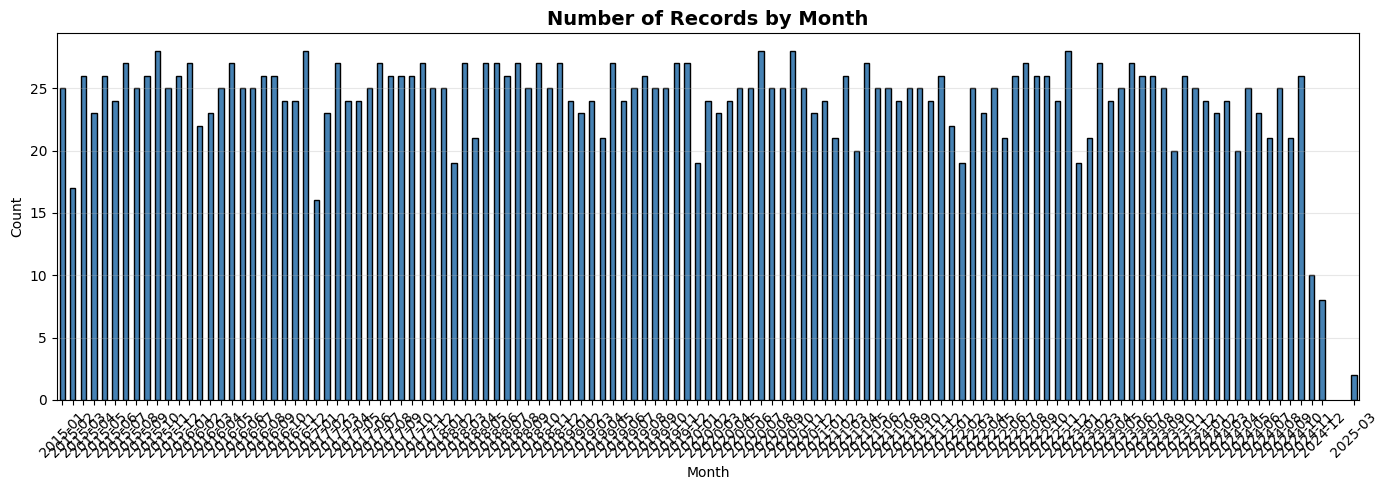

In [32]:
# check number of records by month
df['standard_time'] = pd.to_datetime(df['standard_time'])
df['year_month'] = df['standard_time'].dt.to_period('M')

# Records by month
monthly_count = df.groupby('year_month').size()
print("Records by Month:")
print(monthly_count)
print(f"\nTotal months: {len(monthly_count)}")

# Visualization
plt.figure(figsize=(14, 5))
monthly_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Records by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
df[df['Ngày'].isnull() & (df['standard_time'].isnull() ==False)]

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month


In [34]:
df.drop(columns='Ngày', inplace=True) 

In [35]:
df.head(5)

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
1,315.1,21370.0,NaN,NaT,NaN,NaT
2,282.0,NaN,NaN,NaT,NaN,NaT
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
4,273.2,21370.0,544.45,NaT,NaN,NaT


In [36]:
df.dropna(subset=['standard_time'], inplace=True)

In [37]:
df = df[df['standard_time'] <= pd.to_datetime('2024-10-31')]

In [38]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
...,...,...,...,...,...,...
3584,67081.0,NaN,NaN,2024-10-26,88.00,2024-10
3585,68035.0,NaN,NaN,2024-10-27,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [39]:
df.dropna(subset=['VN_Index'], inplace=True)

In [40]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
8,292.8,21340.0,569.73,2015-01-09,34.30,2015-01
11,267.6,21315.0,574.32,2015-01-12,33.01,2015-01
...,...,...,...,...,...,...
3582,68188.0,25385.0,1257.41,2024-10-24,88.00,2024-10
3583,66734.0,25355.0,1252.72,2024-10-25,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 2246 entries, 5 to 3589
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   BTC_USD        2246 non-null   float64       
 1   USD_VND        2246 non-null   float64       
 2   VN_Index       2246 non-null   float64       
 3   standard_time  2246 non-null   datetime64[us]
 4   Gold_Price     2246 non-null   float64       
 5   year_month     2246 non-null   period[M]     
dtypes: datetime64[us](1), float64(4), period[M](1)
memory usage: 122.8 KB


In [42]:
# convert to datetime and set index
df['standard_time'] = pd.to_datetime(df['standard_time'])
df.set_index('standard_time', inplace=True)

In [43]:
# convert unit of Gold price from million VND/tael to VND/tael
df['Gold_Price'] = df['Gold_Price'] * 1e6

In [44]:
def prepare_data(df):
    # Convert BTC/USD to BTC/VND
    df["BTC_VND"] = df["BTC_USD"] * df["USD_VND"]

    price = df[["VN_Index", "Gold_Price", "BTC_VND", "BTC_USD", "USD_VND"]].dropna()

    log_price = np.log(price)
    log_price.columns = [
        "ln_vnindex",
        "ln_gold",
        "ln_btc_vnd",
        "ln_btc_usd",
        "ln_usdvnd"
    ]

    ret = log_price.diff().dropna()
    ret.columns = [
        "r_vnindex",
        "r_gold",
        "r_btc_vnd",
        "r_btc_usd",
        "r_usdvnd"
    ]

    return price, log_price, ret

price, log_price, ret = prepare_data(df)

In [45]:
for data in [price, log_price, ret]:
    print(data.head())

               VN_Index  Gold_Price    BTC_VND  BTC_USD  USD_VND
standard_time                                                   
2015-01-06       549.66  34900000.0  6113268.0    285.4  21420.0
2015-01-07       552.05  34380000.0  6361740.0    297.0  21420.0
2015-01-08       553.47  33050000.0  6100416.0    285.6  21360.0
2015-01-09       569.73  34300000.0  6248352.0    292.8  21340.0
2015-01-12       574.32  33010000.0  5703894.0    267.6  21315.0
               ln_vnindex    ln_gold  ln_btc_vnd  ln_btc_usd  ln_usdvnd
standard_time                                                          
2015-01-06       6.309300  17.367997   15.625972    5.653892   9.972080
2015-01-07       6.313639  17.352986   15.665812    5.693732   9.972080
2015-01-08       6.316208  17.313532   15.623868    5.654592   9.969275
2015-01-09       6.345163  17.350656   15.647828    5.679490   9.968339
2015-01-12       6.353187  17.312321   15.556660    5.589493   9.967166
               r_vnindex    r_gold  r_btc

In [46]:
price.describe()

,VN_Index,Gold_Price,BTC_VND,BTC_USD,USD_VND
count,2246.000000,2.246000e+03,2.246000e+03,2246.000000,2246.000000
mean,969.624323,4.969996e+07,4.398580e+08,18562.386910,23122.889581
std,259.578214,1.561648e+07,4.843102e+08,20046.704187,819.620315
min,521.880000,3.245000e+07,3.903992e+06,183.000000,21115.000000
25%,742.117500,3.642000e+07,5.418349e+07,2394.650000,22700.000000
50%,976.060000,4.179500e+07,2.172291e+08,9343.450000,23108.000000
75%,1174.242500,6.630000e+07,6.968762e+08,29638.750000,23374.500000
max,1528.570000,9.000000e+07,1.838643e+09,72974.000000,25469.000000


In [47]:
weekly_price.describe()

NameError: name 'weekly_price' is not defined

In [ ]:
def make_weekly_data(price):
    weekly_price = price.resample("W-FRI").last().dropna()
    weekly_log = np.log(weekly_price)
    weekly_ret = weekly_log.diff().dropna()

    weekly_log.columns = [
        "ln_vnindex",
        "ln_gold",
        "ln_btc_vnd",
        "ln_btc_usd",
        "ln_usdvnd"
    ]

    weekly_ret.columns = [
        "r_vnindex",
        "r_gold",
        "r_btc_vnd",
        "r_btc_usd",
        "r_usdvnd"
    ]

    return weekly_price, weekly_log, weekly_ret

weekly_price, weekly_log, weekly_ret = make_weekly_data(price)

In [ ]:
for data in [weekly_price, weekly_log, weekly_ret]:
    print(data.head())

               VN_Index  Gold_Price    BTC_VND  BTC_USD  USD_VND
standard_time                                                   
2015-01-09       569.73  34300000.0  6248352.0    292.8  21340.0
2015-01-16       574.81  35410000.0  4405810.5    206.7  21315.0
2015-01-23       582.38  35640000.0  5010200.0    235.0  21320.0
2015-01-30       576.07  35290000.0  4872269.7    229.1  21267.0
2015-02-06       574.13  34880000.0  4738982.4    223.2  21232.0
               ln_vnindex    ln_gold  ln_btc_vnd  ln_btc_usd  ln_usdvnd
standard_time                                                          
2015-01-09       6.345163  17.350656   15.647828    5.679490   9.968339
2015-01-16       6.354040  17.382505   15.298435    5.331268   9.967166
2015-01-23       6.367123  17.388979   15.426986    5.459586   9.967401
2015-01-30       6.356229  17.379110   15.399070    5.434159   9.964912
2015-02-06       6.352856  17.367424   15.371333    5.408068   9.963265
               r_vnindex    r_gold  r_btc

In [ ]:
price.index.max()

Timestamp('2024-10-31 00:00:00')

### Descriptive statistics:

In [ ]:


def descriptive_stats(data):
    result = pd.DataFrame(index=data.columns)

    result["mean"] = data.mean()
    result["sd"] = data.std()
    result["skewness"] = data.apply(lambda x: skew(x.dropna()))
    result["kurtosis"] = data.apply(lambda x: kurtosis(x.dropna(), fisher=False))

    jb_stats = []
    jb_pvalues = []

    for col in data.columns:
        jb = jarque_bera(data[col].dropna())
        jb_stats.append(jb.statistic)
        jb_pvalues.append(jb.pvalue)

    result["JB_stat"] = jb_stats
    result["JB_pvalue"] = jb_pvalues

    return result

desc_return = descriptive_stats(ret[["r_vnindex", "r_gold", "r_btc_vnd"]])
print(desc_return)

               mean        sd  skewness   kurtosis       JB_stat  JB_pvalue
r_vnindex  0.000371  0.012084 -0.979018   8.297453   2983.689910        0.0
r_gold     0.000417  0.031306 -0.830165  20.373266  28491.582157        0.0
r_btc_vnd  0.002526  0.047375 -0.718338  12.785279   9149.845877        0.0


- Số liệu này minh chứng rõ nét cho nguyên tắc "High risk, high return". Bitcoin mang lại lợi nhuận cao nhất nhưng rủi ro đi kèm cũng lớn nhất. Điều này một lần nữa làm yếu đi luận điểm coi Bitcoin là một tài sản "trú ẩn an toàn" (safe haven) ổn định như Vàng.
- Việc skewness âm cho thấy chuỗi lợi nhuận của các tài sản này có xu hướng mang lại những khoản lãi nhỏ thường xuyên, nhưng thỉnh thoảng sẽ có những cú sụt giảm giá trị cực mạnh (downside risk). Trong đó, VN-Index có mức độ lệch âm cao nhất.
- Các sự kiện cực đoan (những ngày giá tăng phi mã hoặc sập hầm) xảy ra dày đặc hơn nhiều so với dự báo của phân phối chuẩn. Đặc biệt, Vàng có Kurtosis lên tới >20, nghĩa là bình thường giá Vàng biến động rất nhỏ (tập trung ở đỉnh nhọn), nhưng một khi có cú sốc vĩ mô xảy ra, nó sẽ phản ứng với biên độ cực kỳ dữ dội ở vùng "đuôi".
- Với p-value bằng 0, chúng ta bác bỏ hoàn toàn giả thuyết $H_0$ ở mức ý nghĩa 1%. Chuỗi lợi nhuận của VN-Index, Vàng và Bitcoin chắc chắn không tuân theo phân phối chuẩn.

In [ ]:
corr_matrix = ret[["r_vnindex", "r_gold", "r_btc_vnd"]].corr()
print(corr_matrix)

           r_vnindex    r_gold  r_btc_vnd
r_vnindex   1.000000 -0.013212   0.071331
r_gold     -0.013212  1.000000  -0.029976
r_btc_vnd   0.071331 -0.029976   1.000000


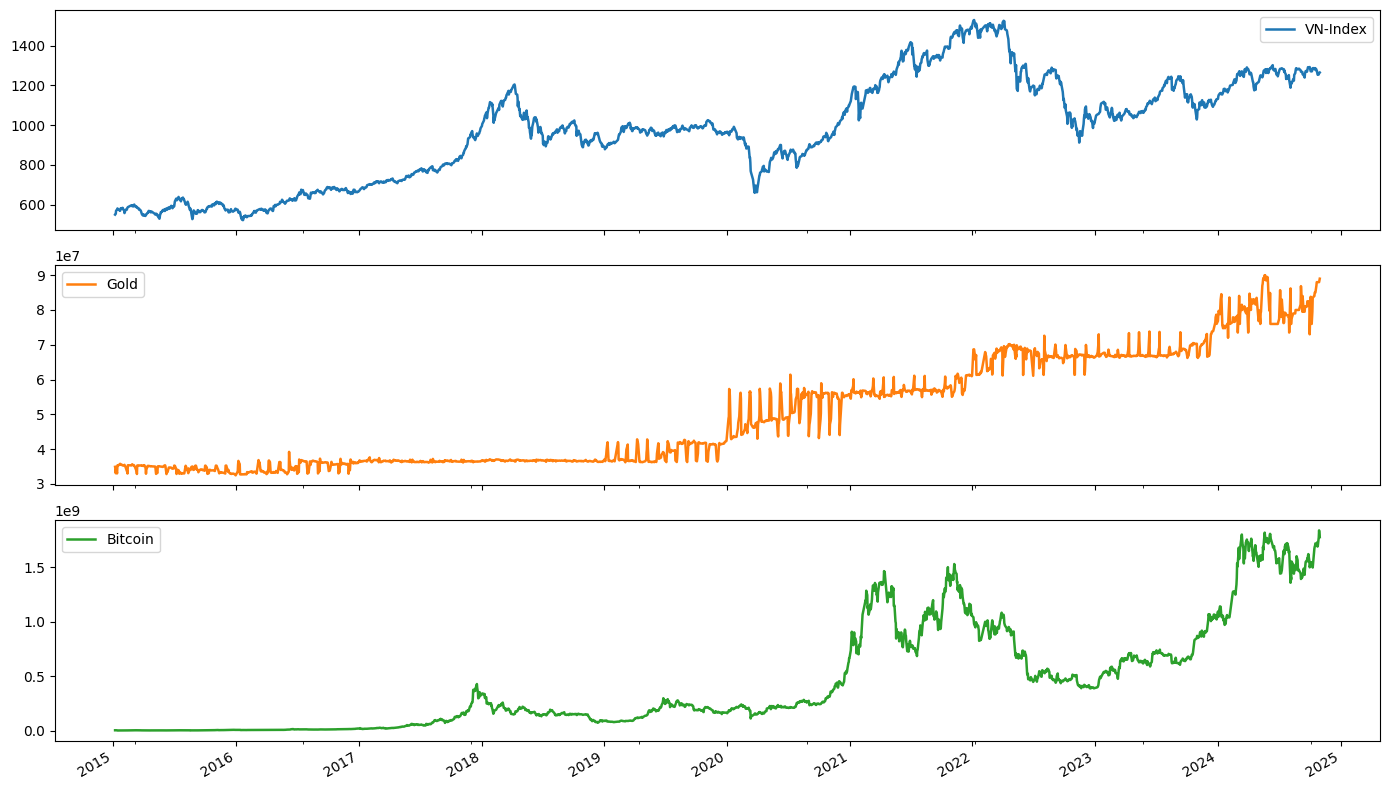

In [ ]:
axes = price[["VN_Index", "Gold_Price", "BTC_VND"]].rename(columns={
    "VN_Index": "VN-Index",
    "Gold_Price": "Gold",
    "BTC_VND": "Bitcoin"
}).plot(
    subplots=True,
    figsize=(14, 8),
    sharex=True,
    linewidth=1.8
)

# Bỏ title trục x
axes[-1].set_xlabel("")

plt.tight_layout()
plt.show()

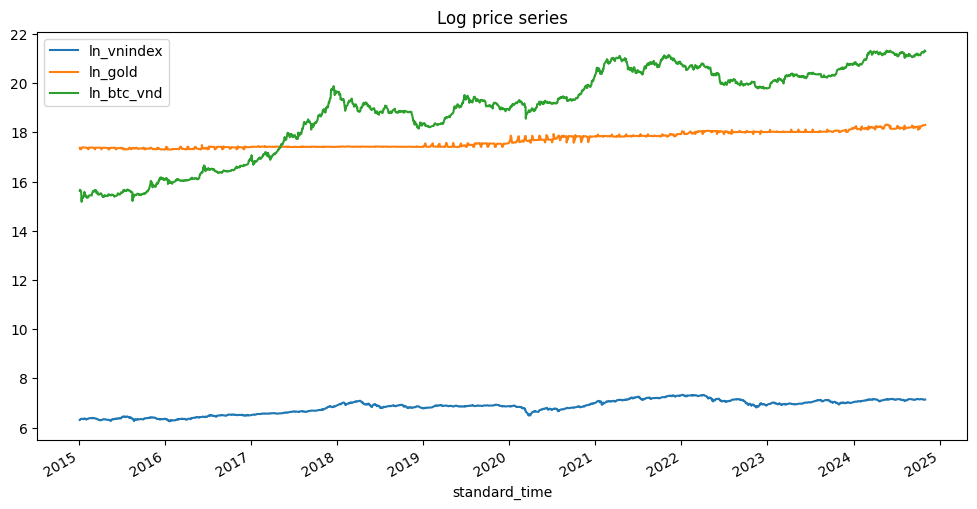

In [ ]:
log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].plot(figsize=(12, 6))
plt.title("Log price series")
plt.show()

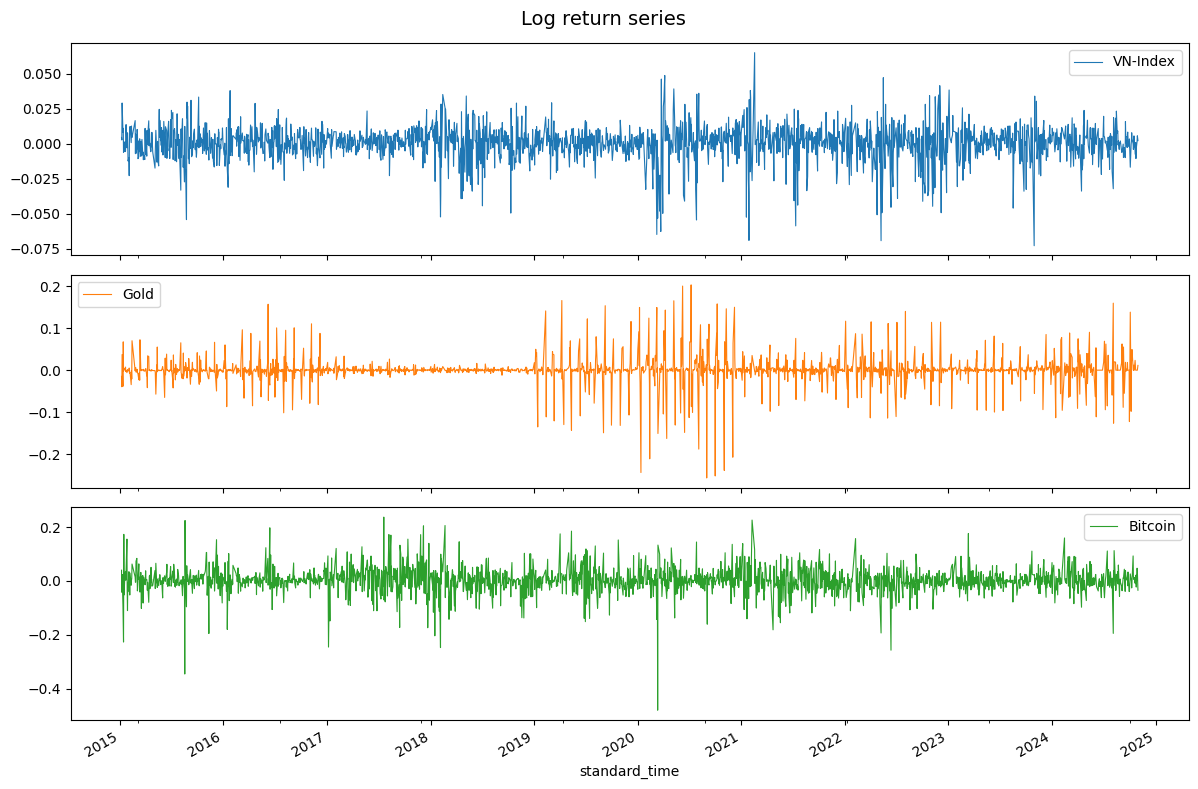

In [ ]:
ret[["r_vnindex", "r_gold", "r_btc_vnd"]].rename(columns={
    "r_vnindex": "VN-Index",
    "r_gold": "Gold",
    "r_btc_vnd": "Bitcoin"
}).plot(
    subplots=True,
    figsize=(12, 8),
    sharex=True,
    linewidth=0.8
)

plt.suptitle("Log return series", fontsize=14)
plt.tight_layout()
plt.show()

### Unit root test

In [49]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

def unit_root_tests(data, regression="c"):
    rows = []

    for col in data.columns:
        x      = data[col].dropna()
        x_diff = x.diff().dropna()          # first difference

        for series, label in [(x, "Level"), (x_diff, "1st Diff")]:

            adf_res  = adfuller(series, autolag="AIC", regression=regression)
            pp_res   = PhillipsPerron(series, trend=regression)

            try:
                kpss_res  = kpss(series, regression=regression, nlags="auto")
                kpss_stat = kpss_res[0]
                kpss_p    = kpss_res[1]
            except Exception:
                kpss_stat = np.nan
                kpss_p    = np.nan

            rows.append({
                "Variable"  : col,
                "Form"      : label,
                "ADF_stat"  : adf_res[0],
                "ADF_pvalue": adf_res[1],
                "PP_stat"   : pp_res.stat,
                "PP_pvalue" : pp_res.pvalue,
                "KPSS_stat" : kpss_stat,
                "KPSS_p"    : kpss_p
            })

    return pd.DataFrame(rows)

# Test log price level
unit_log = unit_root_tests(log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]])
print(unit_log)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res  = kpss(series, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res  = kpss(series, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res  = kpss(series, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is

     Variable      Form   ADF_stat    ADF_pvalue    PP_stat  PP_pvalue  \
0  ln_vnindex     Level  -1.540742  5.132692e-01  -1.641885   0.461276   
1  ln_vnindex  1st Diff -13.400288  4.580596e-25 -45.139916   0.000000   
2     ln_gold     Level   1.310463  9.966669e-01  -0.320242   0.922588   
3     ln_gold  1st Diff -16.076381  5.437506e-29 -85.893987   0.000000   
4  ln_btc_vnd     Level  -1.207662  6.702912e-01  -1.239786   0.656251   
5  ln_btc_vnd  1st Diff -49.863424  0.000000e+00 -49.840181   0.000000   

   KPSS_stat  KPSS_p  
0   5.820096    0.01  
1   0.083690    0.10  
2   7.254191    0.01  
3   0.321577    0.10  
4   6.595908    0.01  
5   0.133534    0.10  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res  = kpss(series, regression=regression, nlags="auto")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26984\957663455.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res  = kpss(series, regression=regression, nlags="auto")


- Log price xuất hiện unit root
- return không xuất hiện unit root

### Johansen Cointegration test

In [30]:
levels = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].dropna()

# Chọn lag cho VECM
lag_order = select_order(levels, maxlags=10, deterministic="ci")
print(lag_order.summary())
# lag_order đã được -1 so với lag của var
k_ar_diff = lag_order.hqic
print("Selected k_ar_diff:", k_ar_diff)

# Johansen rank test
rank_test = select_coint_rank(
    levels,
    det_order=0,
    k_ar_diff=k_ar_diff,
    method="trace",
    signif=0.05
)

print(rank_test.summary())
print("Cointegration rank:", rank_test.rank)

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.90     -21.86*   3.095e-10      -21.88
1       -21.91      -21.85   3.047e-10      -21.89
2       -21.91      -21.83   3.046e-10      -21.88
3       -21.93      -21.82   2.999e-10      -21.89
4       -21.96      -21.83   2.907e-10      -21.91
5       -21.97      -21.82   2.866e-10     -21.92*
6       -21.98      -21.80   2.858e-10      -21.91
7       -21.98      -21.78   2.843e-10      -21.91
8       -21.98      -21.76   2.835e-10      -21.90
9      -21.99*      -21.74  2.831e-10*      -21.90
10      -21.98      -21.71   2.838e-10      -21.88
--------------------------------------------------
Selected k_ar_diff: 5
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   3          30.72          29.80
  1   3          

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Cointegration rank: 1 đã xác nhận hệ thống 3 biến (VN-Index, Vàng, Bitcoin) có chính xác 1 mối quan hệ đồng tích hợp (1 phương trình cân bằng dài hạn).

In [31]:
johansen_res = coint_johansen(levels, det_order=0, k_ar_diff=k_ar_diff)

johansen_table = pd.DataFrame({
    "trace_stat": johansen_res.trace_stat,
    "crit_90": johansen_res.trace_stat_crit_vals[:, 0],
    "crit_95": johansen_res.trace_stat_crit_vals[:, 1],
    "crit_99": johansen_res.trace_stat_crit_vals[:, 2]
})

print(johansen_table)

   trace_stat  crit_90  crit_95  crit_99
0   30.724932  27.0669  29.7961  35.4628
1    7.840672  13.4294  15.4943  19.9349
2    0.818069   2.7055   3.8415   6.6349


### VECM model

In [32]:
def fit_vecm_main(levels, rank_test, k_ar_diff, deterministic_type="ci"):
    coint_rank = rank_test.rank

    if coint_rank <= 0:
        raise ValueError("No cointegration detected. Không nên chạy VECM.")

    vecm_model = VECM(
        endog=levels,
        k_ar_diff=k_ar_diff,
        coint_rank=coint_rank,
        deterministic=deterministic_type
    )

    vecm_res = vecm_model.fit()

    beta = pd.DataFrame(
        vecm_res.beta,
        index=levels.columns,
        columns=[f"beta_coint_{i+1}" for i in range(coint_rank)]
    )

    beta_norm = beta.copy()
    for col in beta_norm.columns:
        beta_norm[col] = beta_norm[col] / beta_norm.loc["ln_vnindex", col]

    alpha = pd.DataFrame(
        vecm_res.alpha,
        index=levels.columns,
        columns=[f"ECT_{i+1}" for i in range(coint_rank)]
    )

    alpha_pvalues = pd.DataFrame(
        vecm_res.pvalues_alpha,
        index=levels.columns,
        columns=[f"ECT_{i+1}" for i in range(coint_rank)]
    )

    ect = pd.DataFrame(
        levels.values @ vecm_res.beta,
        index=levels.index,
        columns=[f"ECT_{i+1}" for i in range(coint_rank)]
    )

    vecm_resid = pd.DataFrame(
        vecm_res.resid,
        index=levels.index[-vecm_res.resid.shape[0]:],
        columns=[
            "resid_vnindex",
            "resid_gold",
            "resid_btc_vnd"
        ]
    )

    outputs = {
        "model": vecm_model,
        "result": vecm_res,
        "beta": beta,
        "beta_normalized": beta_norm,
        "alpha": alpha,
        "alpha_pvalues": alpha_pvalues,
        "ect": ect,
        "residuals": vecm_resid,
        "residuals_pct": vecm_resid * 100
    }

    return outputs

In [33]:
vecm_out = fit_vecm_main(
    levels=levels,
    rank_test=rank_test,
    k_ar_diff=k_ar_diff,
    deterministic_type="ci"
)

vecm_res = vecm_out["result"]
beta = vecm_out["beta"]
beta_norm = vecm_out["beta_normalized"]
alpha = vecm_out["alpha"]
alpha_pvalues = vecm_out["alpha_pvalues"]
ect = vecm_out["ect"]
vecm_resid_pct = vecm_out["residuals_pct"]

print(vecm_res.summary())
print("\nBeta normalized:")
print(beta_norm)
print("\nAlpha:")
print(alpha)
print("\nAlpha p-values:")
print(alpha_pvalues)

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation ln_vnindex
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.ln_vnindex     0.0396      0.021      1.885      0.059      -0.002       0.081
L1.ln_gold        0.0035      0.008      0.419      0.675      -0.013       0.020
L1.ln_btc_vnd     0.0163      0.005      3.025      0.002       0.006       0.027
L2.ln_vnindex     0.0310      0.021      1.473      0.141      -0.010       0.072
L2.ln_gold       -0.0030      0.008     -0.356      0.722      -0.019       0.013
L2.ln_btc_vnd     0.0046      0.005      0.854      0.393      -0.006       0.015
L3.ln_vnindex     0.0149      0.021      0.711      0.477      -0.026       0.056
L3.ln_gold        0.0016      0.008      0.195      0.845      -0.015       0.018
L3.ln_btc_vnd     0.0095      0.005      1.767      0.077      -0.001       0.020
L4.ln_vn

Vector đồng liên kết được chuẩn hóa theo VN-Index cho thấy tồn tại quan hệ cân bằng dài hạn giữa VN-Index, vàng và Bitcoin. Sau khi chuyển vế, vàng có quan hệ ngược chiều với VN-Index trong dài hạn, trong khi Bitcoin có quan hệ cùng chiều với VN-Index.

Hệ số điều chỉnh cho thấy VN-Index và Bitcoin phản ứng có ý nghĩa thống kê trước sai lệch khỏi cân bằng dài hạn. Ngược lại, hệ số điều chỉnh của vàng không có ý nghĩa thống kê, gợi ý rằng vàng có thể là biến weakly exogenous trong quan hệ dài hạn.

In [34]:
ect = levels @ beta_norm
ect.name = "ECT"

print(ect.head())

               beta_coint_1
standard_time              
2015-01-06         6.867815
2015-01-07         6.862365
2015-01-08         6.864790
2015-01-09         6.896585
2015-01-12         6.913265


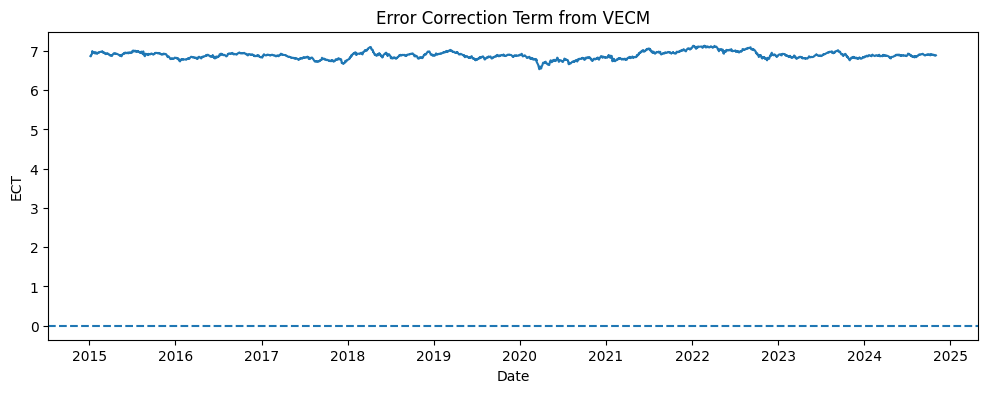

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(ect)
plt.axhline(0, linestyle="--")
plt.title("Error Correction Term from VECM")
plt.xlabel("Date")
plt.ylabel("ECT")
plt.show()

#### residual autocorrelation test

In [36]:
# ==============================
# 5.7 Residual autocorrelation
# ==============================

whiteness_test = vecm_res.test_whiteness(nlags=20)
print("\nWhiteness / residual autocorrelation test:")
print(whiteness_test.summary())


Whiteness / residual autocorrelation test:
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 20 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         340.8          159.8   0.000 132
-----------------------------------------


In [37]:
vecm_resid = pd.DataFrame(
    vecm_res.resid,
    index=levels.index[-vecm_res.resid.shape[0]:],
    columns=["resid_vnindex", "resid_gold", "resid_btc_vnd"]
)

print(vecm_resid.head())

               resid_vnindex  resid_gold  resid_btc_vnd
standard_time                                          
2015-01-14         -0.004769    0.002179      -0.224688
2015-01-15          0.007038    0.011360       0.156693
2015-01-16         -0.004996    0.011901      -0.024916
2015-01-19         -0.001629    0.016706       0.028028
2015-01-20          0.004022   -0.001401       0.032174


In [38]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
import statsmodels.api as sm

def multivariate_lm_serial_test(residuals, nlags=1):
    """
    Multivariate LM/Breusch-Godfrey style serial correlation test
    for VECM/VAR residuals.

    residuals: DataFrame, columns are residuals of each equation.
    nlags: number of lagged residuals included in auxiliary regression.

    Returns:
        LM statistic, degrees of freedom, p-value.
    """

    U = residuals.dropna().copy()
    k = U.shape[1]

    # Lagged residuals
    lagged_parts = []
    for lag in range(1, nlags + 1):
        lagged = U.shift(lag)
        lagged.columns = [f"{col}_lag{lag}" for col in U.columns]
        lagged_parts.append(lagged)

    X = pd.concat(lagged_parts, axis=1)
    X = sm.add_constant(X)

    data = pd.concat([U, X], axis=1).dropna()

    Y = data[U.columns]
    X_full = data[X.columns]

    # Restricted model: residuals chỉ có constant
    X_restricted = np.ones((len(Y), 1))

    # Estimate unrestricted and restricted covariance matrices
    E_unrestricted = []
    E_restricted = []

    for col in U.columns:
        y = Y[col].values

        res_ur = sm.OLS(y, X_full).fit()
        res_r = sm.OLS(y, X_restricted).fit()

        E_unrestricted.append(res_ur.resid)
        E_restricted.append(res_r.resid)

    E_unrestricted = np.column_stack(E_unrestricted)
    E_restricted = np.column_stack(E_restricted)

    Sigma_ur = E_unrestricted.T @ E_unrestricted / len(Y)
    Sigma_r = E_restricted.T @ E_restricted / len(Y)

    # LR/LM-style statistic
    lm_stat = len(Y) * (
        np.log(np.linalg.det(Sigma_r)) - np.log(np.linalg.det(Sigma_ur))
    )

    df = k * k * nlags
    pvalue = chi2.sf(lm_stat, df)

    return {
        "nlags": nlags,
        "LM_stat": lm_stat,
        "df": df,
        "pvalue": pvalue,
        "conclusion_5pct": (
            "Reject H0: system residual autocorrelation"
            if pvalue < 0.05
            else "Fail to reject H0: no system residual autocorrelation"
        )
    }

In [39]:
def multivariate_lm_lag_table(residuals, max_lag=20):
    rows = []

    for lag in range(1, max_lag + 1):
        result = multivariate_lm_serial_test(
            residuals=residuals,
            nlags=lag
        )
        rows.append(result)

    return pd.DataFrame(rows)

lm_system_table = multivariate_lm_lag_table(
    residuals=vecm_resid,
    max_lag=20
)

print(lm_system_table)

    nlags     LM_stat   df        pvalue  \
0       1    0.549869    9  9.999543e-01   
1       2    2.540529   18  9.999924e-01   
2       3    6.277811   27  9.999879e-01   
3       4   10.263605   36  9.999923e-01   
4       5   14.995146   45  9.999927e-01   
5       6   56.074707   54  3.969915e-01   
6       7   88.330664   63  1.934112e-02   
7       8  110.010892   72  2.634519e-03   
8       9  128.595101   81  6.040449e-04   
9      10  139.685065   90  6.202807e-04   
10     11  162.385300   99  6.168324e-05   
11     12  198.544165  108  2.566332e-07   
12     13  220.988856  117  2.124881e-08   
13     14  252.155351  126  1.881962e-10   
14     15  296.404228  135  4.025756e-14   
15     16  325.854227  144  4.060367e-16   
16     17  340.093458  153  2.982932e-16   
17     18  362.526089  162  2.178053e-17   
18     19  396.723338  171  5.516800e-20   
19     20  423.823089  180  1.028329e-21   

                                      conclusion_5pct  
0   Fail to reject 

#### normality test

In [45]:
# ==============================
# 5.8 Residual normality
# ==============================

normality_test = vecm_res.test_normality()
print("\nResidual normality test:")
print(normality_test.summary())


Residual normality test:
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     3.794e+04          12.59   0.000  6
----------------------------------------


#### ARCH test

In [46]:
# ==============================
# 5.9 ARCH effect
# ==============================

for col in vecm_resid_pct.columns:
    arch_test = het_arch(vecm_resid_pct[col].dropna(), nlags=10)

    print(f"\nARCH-LM test for {col}")
    print("LM statistic:", arch_test[0])
    print("p-value:", arch_test[1])

    if arch_test[1] < 0.05:
        print("=> Có ARCH effect, dùng GARCH/DCC-GARCH là hợp lý.")
    else:
        print("=> Chưa có bằng chứng ARCH effect rõ ràng.")


ARCH-LM test for resid_vnindex
LM statistic: 245.68394276605156
p-value: 4.383707635635478e-47
=> Có ARCH effect, dùng GARCH/DCC-GARCH là hợp lý.

ARCH-LM test for resid_gold
LM statistic: 61.217099354868225
p-value: 2.1310633590844355e-09
=> Có ARCH effect, dùng GARCH/DCC-GARCH là hợp lý.

ARCH-LM test for resid_btc_vnd
LM statistic: 25.675934102500335
p-value: 0.0042013730988179785
=> Có ARCH effect, dùng GARCH/DCC-GARCH là hợp lý.


#### stability test

In [47]:
# ==============================
# 5.10 Stability check of VAR representation
# ==============================

def companion_matrix_from_var_coefs(A):
    """
    A shape: (p, k, k)
    Return companion matrix of VAR(p)
    """
    p, k, _ = A.shape

    top = np.hstack(A)

    if p == 1:
        return top

    bottom_left = np.eye(k * (p - 1))
    bottom_right = np.zeros((k * (p - 1), k))

    bottom = np.hstack([bottom_left, bottom_right])

    return np.vstack([top, bottom])


A = vecm_res.var_rep
companion = companion_matrix_from_var_coefs(A)

eigvals = np.linalg.eigvals(companion)
abs_eigvals = np.abs(eigvals)

eig_table = pd.DataFrame({
    "eigenvalue": eigvals,
    "abs_eigenvalue": abs_eigvals
}).sort_values("abs_eigenvalue", ascending=False)

print("\nEigenvalues of VECM-implied VAR representation:")
print(eig_table)

# Với K biến và rank r, số unit roots kỳ vọng là K-r
k = levels.shape[1]
expected_unit_roots = k - rank_test.rank

near_unit = np.sum(np.isclose(abs_eigvals, 1.0, atol=1e-2))
print("\nExpected number of unit roots:", expected_unit_roots)
print("Approximate number of unit roots:", near_unit)


Eigenvalues of VECM-implied VAR representation:
            eigenvalue  abs_eigenvalue
16  1.000000+0.000000j        1.000000
17  1.000000+0.000000j        1.000000
15  0.987680+0.000000j        0.987680
8   0.488122+0.577735j        0.756334
9   0.488122-0.577735j        0.756334
0  -0.573568+0.000000j        0.573568
1  -0.434588+0.343050j        0.553670
2  -0.434588-0.343050j        0.553670
5  -0.258459-0.475123j        0.540872
4  -0.258459+0.475123j        0.540872
14  0.531330+0.000000j        0.531330
11  0.194102-0.489524j        0.526602
10  0.194102+0.489524j        0.526602
7  -0.158847-0.443800j        0.471371
6  -0.158847+0.443800j        0.471371
13  0.437225+0.000000j        0.437225
3  -0.385962+0.000000j        0.385962
12  0.143108+0.000000j        0.143108

Expected number of unit roots: 2
Approximate number of unit roots: 2


#### Granger causality

In [48]:

names = ["ln_vnindex", "ln_gold", "ln_btc_vnd"]

tests = [
    ("Gold → VNIndex", ["ln_vnindex"], ["ln_gold"]),
    ("Bitcoin → VNIndex", ["ln_vnindex"], ["ln_btc_vnd"]),
    ("Gold + Bitcoin → VNIndex", ["ln_vnindex"], ["ln_gold", "ln_btc_vnd"]),
    
    ("VNIndex → Gold", ["ln_gold"], ["ln_vnindex"]),
    ("Bitcoin → Gold", ["ln_gold"], ["ln_btc_vnd"]),
    ("VNIndex + Bitcoin → Gold", ["ln_gold"], ["ln_vnindex", "ln_btc_vnd"]),
    
    ("VNIndex → Bitcoin", ["ln_btc_vnd"], ["ln_vnindex"]),
    ("Gold → Bitcoin", ["ln_btc_vnd"], ["ln_gold"]),
    ("VNIndex + Gold → Bitcoin", ["ln_btc_vnd"], ["ln_vnindex", "ln_gold"]),
]

results = []

for label, caused, causing in tests:
    test_res = vecm_res.test_granger_causality(
        caused=caused,
        causing=causing,
        signif=0.05
    )
    
    stat = getattr(test_res, "test_statistic", np.nan)
    pval = getattr(test_res, "pvalue", np.nan)
    
    results.append({
        "Test": label,
        "H0": f"{causing} do not Granger-cause {caused}",
        "Test statistic": stat,
        "p-value": pval,
        "Reject H0 at 5%": pval < 0.05
    })

granger_table = pd.DataFrame(results)


In [49]:
granger_table

,Test,H0,Test statistic,p-value,Reject H0 at 5%
0,Gold → VNIndex,['ln_gold'] do not Granger-cause ['ln_vnindex'],1.128611,0.342618,False
1,Bitcoin → VNIndex,['ln_btc_vnd'] do not Granger-cause ['ln_vnind...,4.534805,0.000135,True
2,Gold + Bitcoin → VNIndex,"['ln_gold', 'ln_btc_vnd'] do not Granger-cause...",2.803098,0.000786,True
3,VNIndex → Gold,['ln_vnindex'] do not Granger-cause ['ln_gold'],0.628121,0.707931,False
4,Bitcoin → Gold,['ln_btc_vnd'] do not Granger-cause ['ln_gold'],1.448395,0.191942,False
5,VNIndex + Bitcoin → Gold,"['ln_vnindex', 'ln_btc_vnd'] do not Granger-ca...",1.062333,0.387817,False
6,VNIndex → Bitcoin,['ln_vnindex'] do not Granger-cause ['ln_btc_v...,0.729099,0.626138,False
7,Gold → Bitcoin,['ln_gold'] do not Granger-cause ['ln_btc_vnd'],1.908709,0.075536,False
8,VNIndex + Gold → Bitcoin,"['ln_vnindex', 'ln_gold'] do not Granger-cause...",1.311822,0.203673,False


Kết quả kiểm định nhân quả Granger cho thấy cơ chế truyền động ngắn hạn bất đối xứng giữa ba tài sản. Bitcoin có quan hệ nhân quả Granger đáng kể với VN-Index, cho thấy Bitcoin chứa thông tin dự báo cho thị trường chứng khoán Việt Nam. Ngược lại, vàng không có quan hệ nhân quả đáng kể với VN-Index và cũng không phản ứng rõ ràng trước các cú sốc từ các biến còn lại. Điều này gợi ý rằng Bitcoin đóng vai trò tích cực hơn trong cơ chế truyền dẫn thông tin ngắn hạn, trong khi vàng hoạt động độc lập và mang tính weakly exogenous nhiều hơn trong hệ thống.

#### GIRF

In [50]:
def get_ma_rep_from_vecm(vecm_res, H):
    """
    Lấy MA representation từ VECM.
    H = số kỳ phản ứng.
    """
    if hasattr(vecm_res, "ma_rep"):
        ma = vecm_res.ma_rep(maxn=H + 1)
    else:
        ma = vecm_res.irf(H).irfs
    
    return ma


def compute_girf(vecm_res, H=20):
    """
    Tính Generalized Impulse Response Function theo Pesaran-Shin.
    
    Output shape:
    girf[h, response_variable, shock_variable]
    """
    ma = get_ma_rep_from_vecm(vecm_res, H)
    
    if hasattr(vecm_res, "sigma_u"):
        Sigma = vecm_res.sigma_u
    else:
        Sigma = np.cov(vecm_res.resid, rowvar=False)
    
    Sigma = np.asarray(Sigma)
    k = Sigma.shape[0]
    
    girf = np.zeros((H + 1, k, k))
    
    for j in range(k):
        e_j = np.zeros(k)
        e_j[j] = 1
        
        shock_j = Sigma @ e_j / np.sqrt(Sigma[j, j])
        
        for h in range(H + 1):
            girf[h, :, j] = ma[h] @ shock_j
    
    return girf

In [51]:
H = 20
girf = compute_girf(vecm_res, H=H)

names = levels.columns.tolist()

In [52]:
def plot_girf_response(girf, names, response_var, shock_var, H=20, lower=None, upper=None):
    response_idx = names.index(response_var)
    shock_idx = names.index(shock_var)
    
    horizon = np.arange(H + 1)
    y = girf[:, response_idx, shock_idx]
    
    plt.figure(figsize=(8, 4))
    plt.plot(horizon, y, label="GIRF")
    plt.axhline(0, linestyle="--", linewidth=1)
    
    if lower is not None and upper is not None:
        lo = lower[:, response_idx, shock_idx]
        up = upper[:, response_idx, shock_idx]
        plt.fill_between(horizon, lo, up, alpha=0.2, label="95% bootstrap CI")
    
    plt.title(f"Response of {response_var} to shock in {shock_var}")
    plt.xlabel("Horizon")
    plt.ylabel("Response")
    plt.legend()
    plt.show()

In [53]:
def get_coint_const_effect(vecm_res):
    """
    Lấy phần deterministic effect trong VECM.
    Code này phù hợp nhất nếu bạn dùng deterministic='ci'.
    """
    k, r = vecm_res.alpha.shape
    const = np.zeros(k)
    
    if hasattr(vecm_res, "det_coef_coint"):
        dc = np.asarray(vecm_res.det_coef_coint)
        
        if dc.size > 0:
            # Thường shape là: n_det_coint x r
            if dc.shape[1] == r:
                c = dc[0, :].reshape(r, 1)
            elif dc.shape[0] == r:
                c = dc[:, 0].reshape(r, 1)
            else:
                c = None
            
            if c is not None:
                const += (vecm_res.alpha @ c).ravel()
    
    if hasattr(vecm_res, "det_coef"):
        d = np.asarray(vecm_res.det_coef)
        if d.size > 0:
            const += d[:, 0]
    
    return const


def block_resample_resid(resid, n_needed, block_len, rng):
    """
    Moving block bootstrap cho residual.
    Phù hợp hơn iid bootstrap nếu residual có volatility clustering.
    """
    T = len(resid)
    blocks = []
    
    while len(blocks) * block_len < n_needed:
        start = rng.integers(0, T - block_len + 1)
        blocks.append(resid[start:start + block_len])
    
    sampled = np.vstack(blocks)
    return sampled[:n_needed]


def simulate_vecm_path(levels, vecm_res, resid_star, k_ar_diff):
    """
    Mô phỏng lại chuỗi level từ VECM đã ước lượng.
    """
    Y_original = np.asarray(levels)
    Y_star = Y_original.copy()
    
    T, k = Y_star.shape
    p = k_ar_diff + 1
    
    Pi = vecm_res.alpha @ vecm_res.beta.T
    
    Gammas = []
    if k_ar_diff > 0:
        for i in range(k_ar_diff):
            G_i = vecm_res.gamma[:, i*k:(i+1)*k]
            Gammas.append(G_i)
    
    const = get_coint_const_effect(vecm_res)
    
    for t in range(p, T):
        dy = const + Pi @ Y_star[t - 1]
        
        for i, G_i in enumerate(Gammas, start=1):
            dy_lag = Y_star[t - i] - Y_star[t - i - 1]
            dy += G_i @ dy_lag
        
        dy += resid_star[t - p]
        Y_star[t] = Y_star[t - 1] + dy
    
    return Y_star


def bootstrap_girf_ci(
    levels,
    vecm_res,
    k_ar_diff,
    coint_rank,
    deterministic="ci",
    H=20,
    B=500,
    block_len=10,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)
    
    resid = np.asarray(vecm_res.resid)
    T, k = levels.shape
    p = k_ar_diff + 1
    n_needed = T - p
    
    boot_girfs = []
    
    for b in range(B):
        try:
            resid_star = block_resample_resid(
                resid=resid,
                n_needed=n_needed,
                block_len=block_len,
                rng=rng
            )
            
            Y_star = simulate_vecm_path(
                levels=levels,
                vecm_res=vecm_res,
                resid_star=resid_star,
                k_ar_diff=k_ar_diff
            )
            
            Y_star_df = pd.DataFrame(
                Y_star,
                index=levels.index,
                columns=levels.columns
            )
            
            boot_res = VECM(
                Y_star_df,
                k_ar_diff=k_ar_diff,
                coint_rank=coint_rank,
                deterministic=deterministic
            ).fit()
            
            boot_girf = compute_girf(boot_res, H=H)
            boot_girfs.append(boot_girf)
        
        except Exception:
            continue
    
    boot_girfs = np.array(boot_girfs)
    
    print("Successful bootstrap replications:", boot_girfs.shape[0])
    
    lower = np.quantile(boot_girfs, alpha / 2, axis=0)
    upper = np.quantile(boot_girfs, 1 - alpha / 2, axis=0)
    
    return lower, upper, boot_girfs

In [54]:
H = 20
B = 1000

lower, upper, boot_girfs = bootstrap_girf_ci(
    levels=levels,
    vecm_res=vecm_res,
    k_ar_diff=k_ar_diff,
    coint_rank=rank_test.rank,
    deterministic="ci",
    H=H,
    B=B,
    block_len=10,
    alpha=0.05,
    seed=42
)

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

Successful bootstrap replications: 1000


c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


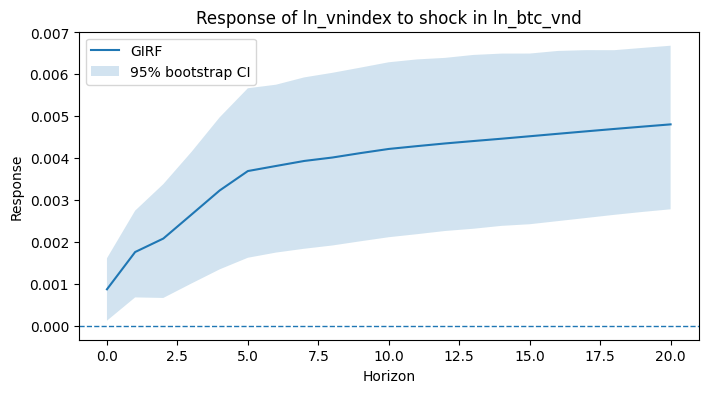

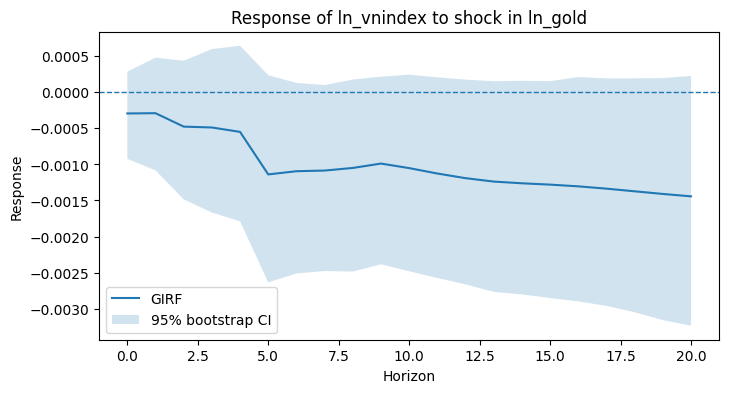

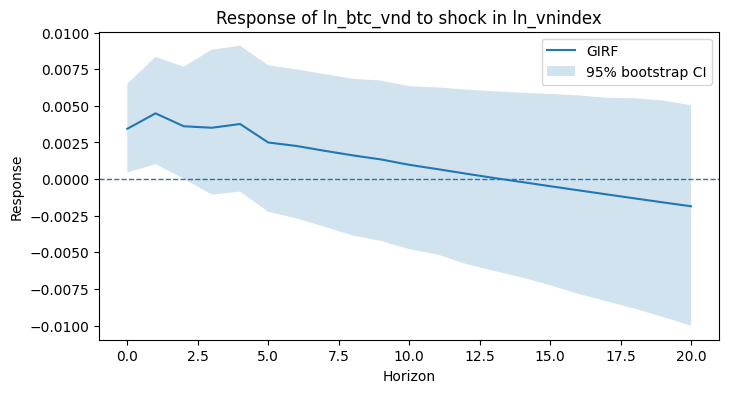

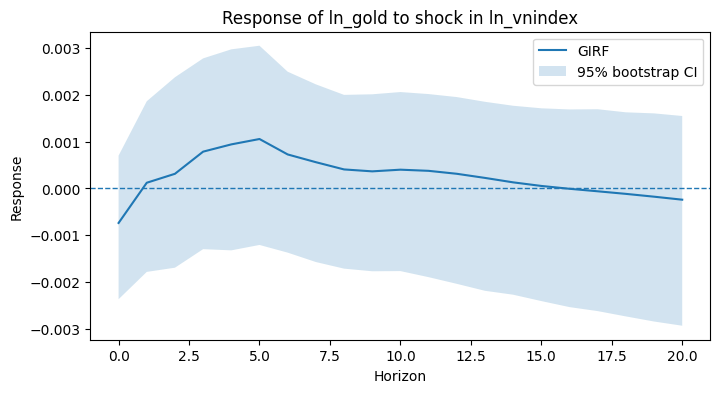

In [55]:
# 1. Main result: Bitcoin shock → VNIndex response
plot_girf_response(girf, names, "ln_vnindex", "ln_btc_vnd", H=20, lower=lower, upper=upper)

# 2. Comparison: Gold shock → VNIndex response
plot_girf_response(girf, names, "ln_vnindex", "ln_gold", H=20, lower=lower, upper=upper)

# 3. Reverse direction: VNIndex shock → Bitcoin response
plot_girf_response(girf, names, "ln_btc_vnd", "ln_vnindex", H=20, lower=lower, upper=upper)

# 4. Gold independence: VNIndex shock → Gold response
plot_girf_response(girf, names, "ln_gold", "ln_vnindex", H=20, lower=lower, upper=upper)

Mặc dù giá trị phản ứng xung có vẻ nhỏ về mặt số học, các biến đều được biểu diễn dưới dạng log nên có thể diễn giải gần đúng theo phần trăm. Cú sốc từ Bitcoin tạo ra phản ứng dương của VN-Index, đạt khoảng 0.5% sau 20 kỳ và khoảng tin cậy bootstrap nằm trên 0. Ngược lại, phản ứng của VN-Index trước cú sốc vàng cũng như phản ứng ngược của Bitcoin và vàng trước cú sốc VN-Index không có ý nghĩa thống kê rõ ràng do khoảng tin cậy bao gồm 0.

#### GFEVD

In [56]:
def compute_gfevd(vecm_res, H=20):
    """
    Generalized Forecast Error Variance Decomposition.
    
    Output:
    row = response variable
    column = shock variable
    """
    ma = get_ma_rep_from_vecm(vecm_res, H - 1)
    
    if hasattr(vecm_res, "sigma_u"):
        Sigma = np.asarray(vecm_res.sigma_u)
    else:
        Sigma = np.cov(vecm_res.resid, rowvar=False)
    
    k = Sigma.shape[0]
    gfevd = np.zeros((k, k))
    
    for i in range(k):  # response variable
        denom = 0
        
        for h in range(H):
            psi_h = ma[h]
            e_i = np.zeros(k)
            e_i[i] = 1
            
            denom += e_i @ psi_h @ Sigma @ psi_h.T @ e_i
        
        for j in range(k):  # shock variable
            num = 0
            
            for h in range(H):
                psi_h = ma[h]
                e_i = np.zeros(k)
                e_i[i] = 1
                
                num += ((e_i @ psi_h @ Sigma[:, j]) ** 2) / Sigma[j, j]
            
            gfevd[i, j] = num / denom
    
    # Row normalization
    gfevd_norm = gfevd / gfevd.sum(axis=1, keepdims=True)
    
    return gfevd_norm

In [57]:
gfevd_10 = compute_gfevd(vecm_res, H=10)
gfevd_20 = compute_gfevd(vecm_res, H=20)

gfevd_10_table = pd.DataFrame(
    gfevd_10 * 100,
    index=names,
    columns=[f"Shock from {x}" for x in names]
)

gfevd_20_table = pd.DataFrame(
    gfevd_20 * 100,
    index=names,
    columns=[f"Shock from {x}" for x in names]
)

print("GFEVD H=10")
print(gfevd_10_table.round(2))

print("\nGFEVD H=20")
print(gfevd_20_table.round(2))

GFEVD H=10
            Shock from ln_vnindex  Shock from ln_gold  Shock from ln_btc_vnd
ln_vnindex                  93.45                0.40                   6.15
ln_gold                      0.12               99.69                   0.19
ln_btc_vnd                   0.41                0.12                  99.47

GFEVD H=20
            Shock from ln_vnindex  Shock from ln_gold  Shock from ln_btc_vnd
ln_vnindex                  89.65                0.72                   9.63
ln_gold                      0.08               99.69                   0.23
ln_btc_vnd                   0.22                0.13                  99.65


Kết quả GFEVD cho thấy biến động sai số dự báo của mỗi biến chủ yếu được giải thích bởi cú sốc của chính nó. Tuy nhiên, trong các hiệu ứng chéo giữa các thị trường, Bitcoin có đóng góp đáng chú ý nhất vào biến động dự báo của VN-Index. Ở chân trời 10 kỳ, cú sốc từ Bitcoin giải thích 6.15% biến động sai số dự báo của VN-Index và tăng lên 9.63% ở chân trời 20 kỳ. Ngược lại, cú sốc từ vàng chỉ giải thích lần lượt 0.40% và 0.72%. Điều này cho thấy Bitcoin có vai trò quan trọng hơn vàng trong việc truyền dẫn các cú sốc ngắn hạn sang thị trường chứng khoán Việt Nam.

#### safe-heaven stress test

In [58]:
returns = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].diff().dropna()

r_m = returns["ln_vnindex"]

q10 = r_m.quantile(0.10)
q5  = r_m.quantile(0.05)
q1  = r_m.quantile(0.01)

D10 = (r_m <= q10).astype(int)
D5  = (r_m <= q5).astype(int)
D1  = (r_m <= q1).astype(int)

print("Total observations:", len(r_m))
print("D10 observations:", D10.sum())
print("D5 observations:", D5.sum())
print("D1 observations:", D1.sum())

print("q10:", q10, "≈", (np.exp(q10)-1)*100, "%")
print("q5:", q5, "≈", (np.exp(q5)-1)*100, "%")
print("q1:", q1, "≈", (np.exp(q1)-1)*100, "%")

Total observations: 2245
D10 observations: 225
D5 observations: 113
D1 observations: 23
q10: -0.011979757954466309 ≈ -1.190828634303931 %
q5: -0.018760192549003917 ≈ -1.8585315420467485 %
q1: -0.0426991988101733 ≈ -4.1800425706182365 %


In [59]:
u = pd.DataFrame(
    vecm_res.resid,
    index=levels.index[-len(vecm_res.resid):],
    columns=["u_vnindex", "u_gold", "u_btc_vnd"]
)

returns = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].diff().dropna()

safe_df = u.join(
    returns[["ln_vnindex"]].rename(columns={"ln_vnindex": "r_vnindex"}),
    how="inner"
)

In [60]:
safe_df

,u_vnindex,u_gold,u_btc_vnd,r_vnindex
standard_time,,,,
2015-01-14,-0.004769,0.002179,-0.224688,-0.006202
2015-01-15,0.007038,0.011360,0.156693,0.001264
2015-01-16,-0.004996,0.011901,-0.024916,-0.005084
2015-01-19,-0.001629,0.016706,0.028028,-0.005758
2015-01-20,0.004022,-0.001401,0.032174,0.001242
...,...,...,...,...
2024-10-24,-0.010918,0.006151,0.021333,-0.010671
2024-10-25,-0.004053,0.007241,-0.021467,-0.003737
2024-10-28,0.002615,0.006206,0.043635,0.001635


In [61]:
def safe_haven_test_residual(df, asset_col, market_col="u_vnindex", stress_col="r_vnindex", hac_lags=5):
    data = df[[asset_col, market_col, stress_col]].dropna().copy()

    y = data[asset_col]
    m = data[market_col]
    stress = data[stress_col]

    q10 = stress.quantile(0.10)
    q5  = stress.quantile(0.05)
    q1  = stress.quantile(0.01)

    data["D10"] = (stress <= q10).astype(int)
    data["D5"]  = (stress <= q5).astype(int)
    data["D1"]  = (stress <= q1).astype(int)

    data["m"] = m
    data["m_D10"] = data["m"] * data["D10"]
    data["m_D5"]  = data["m"] * data["D5"]
    data["m_D1"]  = data["m"] * data["D1"]

    X = sm.add_constant(data[["m", "m_D10", "m_D5", "m_D1"]])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )

    return model, data, {"q10": q10, "q5": q5, "q1": q1}

In [62]:
gold_resid_model, gold_resid_df, gold_resid_q = safe_haven_test_residual(
    safe_df,
    asset_col="u_gold",
    market_col="u_vnindex",
    stress_col="r_vnindex",
    hac_lags=5
)

btc_resid_model, btc_resid_df, btc_resid_q = safe_haven_test_residual(
    safe_df,
    asset_col="u_btc_vnd",
    market_col="u_vnindex",
    stress_col="r_vnindex",
    hac_lags=5
)

print("Gold residual safe-haven model")
print(gold_resid_model.summary())

print("\nBitcoin residual safe-haven model")
print(btc_resid_model.summary())

Gold residual safe-haven model
                            OLS Regression Results                            
Dep. Variable:                 u_gold   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.596
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.173
Time:                        10:35:57   Log-Likelihood:                 4690.1
No. Observations:                2240   AIC:                            -9370.
Df Residuals:                    2235   BIC:                            -9342.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001

In [63]:
def scalar(x):
    """
    Convert statsmodels test output array to scalar.
    """
    return np.asarray(x).squeeze().item()


def total_slope_tests(model):
    params = model.params.index.tolist()
    
    combos = {
        "Normal slope β0": ["m"],
        "10% stress slope β0+β1": ["m", "m_D10"],
        "5% stress slope β0+β1+β2": ["m", "m_D10", "m_D5"],
        "1% stress slope β0+β1+β2+β3": ["m", "m_D10", "m_D5", "m_D1"],
    }

    rows = []

    for label, terms in combos.items():
        R = np.zeros((1, len(params)))   # sửa thành ma trận 2D
        
        for term in terms:
            R[0, params.index(term)] = 1

        test = model.t_test(R)

        rows.append({
            "Slope": label,
            "Estimate": scalar(test.effect),
            "Std.Err": scalar(test.sd),
            "t-stat": scalar(test.tvalue),
            "p-value": scalar(test.pvalue),
            "Significant 5%": scalar(test.pvalue) < 0.05
        })

    return pd.DataFrame(rows)

In [64]:
gold_resid_slope = total_slope_tests(gold_resid_model)
btc_resid_slope = total_slope_tests(btc_resid_model)

print("Gold residual total slopes")
print(gold_resid_slope)

print("\nBitcoin residual total slopes")
print(btc_resid_slope)

Gold residual total slopes
                         Slope  Estimate   Std.Err    t-stat   p-value  \
0              Normal slope β0  0.044006  0.088975  0.494581  0.620896   
1       10% stress slope β0+β1 -0.256871  0.118258 -2.172113  0.029847   
2     5% stress slope β0+β1+β2 -0.121324  0.101984 -1.189643  0.234187   
3  1% stress slope β0+β1+β2+β3 -0.181120  0.190918 -0.948680  0.342784   

   Significant 5%  
0           False  
1            True  
2           False  
3           False  

Bitcoin residual total slopes
                         Slope  Estimate   Std.Err    t-stat   p-value  \
0              Normal slope β0  0.165531  0.133123  1.243444  0.213704   
1       10% stress slope β0+β1  0.284205  0.264145  1.075944  0.281952   
2     5% stress slope β0+β1+β2  0.014529  0.207899  0.069886  0.944284   
3  1% stress slope β0+β1+β2+β3  0.909604  0.505620  1.798985  0.072021   

   Significant 5%  
0           False  
1           False  
2           False  
3           False  


Kết quả cho thấy vàng có bằng chứng trú ẩn an toàn ở vùng stress 10%, khi hệ số total slope âm và có ý nghĩa thống kê. Tuy nhiên, bằng chứng này không còn rõ ở các vùng stress 5% và 1%. Ngược lại, Bitcoin không thể hiện đặc tính safe haven rõ ràng, do các hệ số trong giai đoạn stress chủ yếu mang dấu dương, đặc biệt ở vùng stress 1% hệ số dương khá lớn và gần có ý nghĩa ở mức 10%.

#### EWMA

In [65]:
def compute_ewma_corr(df, lam=0.94, init_window=60):
    """
    EWMA / RiskMetrics correlation from residuals.

    df: DataFrame gồm các residuals
    lam: decay factor
    init_window: số quan sát đầu dùng để khởi tạo covariance matrix
    """

    data = df.dropna().copy()
    X = data.values
    index = data.index
    names = data.columns.tolist()

    T, k = X.shape

    if T <= init_window:
        raise ValueError("Not enough observations for the chosen init_window.")

    # Khởi tạo bằng sample covariance của init_window đầu tiên
    S = np.cov(X[:init_window].T)

    rows = []
    out_index = []

    for t in range(init_window, T):
        x_lag = X[t - 1].reshape(-1, 1)

        # EWMA covariance update
        S = lam * S + (1 - lam) * (x_lag @ x_lag.T)

        diag = np.sqrt(np.diag(S))
        R = S / np.outer(diag, diag)

        rows.append({
            "rho_vn_gold": R[names.index("u_vnindex"), names.index("u_gold")],
            "rho_vn_btc": R[names.index("u_vnindex"), names.index("u_btc_vnd")],
            "rho_gold_btc": R[names.index("u_gold"), names.index("u_btc_vnd")]
        })

        out_index.append(index[t])

    ewma_corr = pd.DataFrame(rows, index=out_index)

    return ewma_corr

In [66]:
ewma_corr_094 = compute_ewma_corr(
    u,
    lam=0.94,
    init_window=60
)

print(ewma_corr_094.describe())

       rho_vn_gold   rho_vn_btc  rho_gold_btc
count  2180.000000  2180.000000   2180.000000
mean     -0.004112     0.065610     -0.024059
std       0.190911     0.176342      0.182675
min      -0.637830    -0.516892     -0.748011
25%      -0.130605    -0.040310     -0.132873
50%       0.002987     0.072493     -0.014930
75%       0.136231     0.182804      0.100608
max       0.575933     0.693353      0.534360


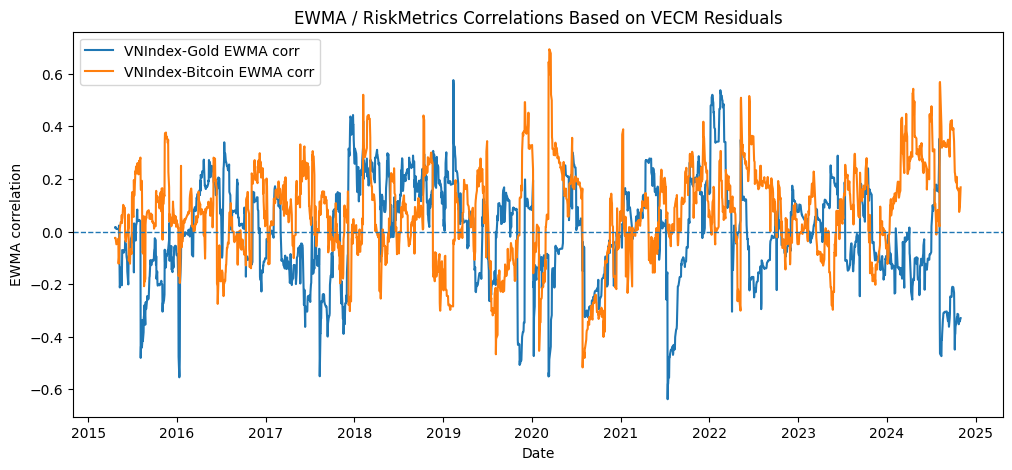

In [67]:
plt.figure(figsize=(12, 5))

plt.plot(
    ewma_corr_094.index,
    ewma_corr_094["rho_vn_gold"],
    label="VNIndex-Gold EWMA corr"
)

plt.plot(
    ewma_corr_094.index,
    ewma_corr_094["rho_vn_btc"],
    label="VNIndex-Bitcoin EWMA corr"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("EWMA / RiskMetrics Correlations Based on VECM Residuals")
plt.ylabel("EWMA correlation")
plt.xlabel("Date")
plt.legend()
plt.show()

In [68]:
returns = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].diff().dropna()

r_m = returns["ln_vnindex"]

q10 = r_m.quantile(0.10)
q5  = r_m.quantile(0.05)
q1  = r_m.quantile(0.01)

stress_df = pd.DataFrame(index=returns.index)
stress_df["r_vnindex"] = r_m
stress_df["D10"] = (r_m <= q10).astype(int)
stress_df["D5"]  = (r_m <= q5).astype(int)
stress_df["D1"]  = (r_m <= q1).astype(int)

ewma_stress = ewma_corr_094.join(stress_df, how="inner")

ewma_stress["normal"] = ewma_stress["r_vnindex"] > q10
ewma_stress["stress_10"] = ewma_stress["r_vnindex"] <= q10
ewma_stress["stress_5"]  = ewma_stress["r_vnindex"] <= q5
ewma_stress["stress_1"]  = ewma_stress["r_vnindex"] <= q1

In [69]:
summary_rows = []

for regime, mask_col in [
    ("Normal", "normal"),
    ("Stress 10%", "stress_10"),
    ("Stress 5%", "stress_5"),
    ("Stress 1%", "stress_1")
]:
    temp = ewma_stress.loc[ewma_stress[mask_col]].copy()

    summary_rows.append({
        "Regime": regime,
        "N": len(temp),

        "Mean EWMA corr VN-Gold": temp["rho_vn_gold"].mean(),
        "Median EWMA corr VN-Gold": temp["rho_vn_gold"].median(),
        "Share negative VN-Gold": (temp["rho_vn_gold"] < 0).mean(),

        "Mean EWMA corr VN-BTC": temp["rho_vn_btc"].mean(),
        "Median EWMA corr VN-BTC": temp["rho_vn_btc"].median(),
        "Share negative VN-BTC": (temp["rho_vn_btc"] < 0).mean(),

        "Mean EWMA corr Gold-BTC": temp["rho_gold_btc"].mean(),
        "Median EWMA corr Gold-BTC": temp["rho_gold_btc"].median()
    })

ewma_regime_summary = pd.DataFrame(summary_rows)

print(ewma_regime_summary.round(4))

       Regime     N  Mean EWMA corr VN-Gold  Median EWMA corr VN-Gold  \
0      Normal  1957                 -0.0067                   -0.0012   
1  Stress 10%   223                  0.0186                    0.0380   
2   Stress 5%   112                  0.0195                    0.0435   
3   Stress 1%    23                 -0.0516                   -0.0558   

   Share negative VN-Gold  Mean EWMA corr VN-BTC  Median EWMA corr VN-BTC  \
0                  0.5023                 0.0648                   0.0753   
1                  0.4439                 0.0725                   0.0498   
2                  0.4464                 0.0798                   0.0483   
3                  0.5652                 0.1257                   0.0273   

   Share negative VN-BTC  Mean EWMA corr Gold-BTC  Median EWMA corr Gold-BTC  
0                 0.3316                  -0.0264                    -0.0160  
1                 0.3453                  -0.0037                    -0.0040  
2          

Kết quả từ mô hình safe-haven dựa trên phần dư VECM cho thấy bằng chứng về vai trò trú ẩn của vàng là có tồn tại nhưng không hoàn toàn nhất quán ở mọi mức độ căng thẳng thị trường. Cụ thể, hệ số total slope của vàng trong vùng stress 10% mang dấu âm và có ý nghĩa thống kê ở mức 5%, cho thấy khi VN-Index rơi vào nhóm 10% ngày giảm mạnh nhất, cú sốc của vàng có xu hướng biến động ngược chiều với cú sốc của VN-Index. Đây là bằng chứng ủng hộ vai trò safe haven của vàng trong giai đoạn thị trường suy giảm tương đối rộng. Tuy nhiên, ở các ngưỡng stress nghiêm trọng hơn như 5% và 1%, mặc dù hệ số của vàng vẫn mang dấu âm, các hệ số này không có ý nghĩa thống kê. Do đó, chưa thể kết luận rằng vàng là tài sản trú ẩn mạnh và ổn định trong mọi trạng thái thị trường cực đoan.

Kết quả EWMA/RiskMetrics correlation cung cấp thêm bằng chứng bổ sung nhưng cũng cho thấy vai trò trú ẩn của vàng có tính phụ thuộc trạng thái. Trong giai đoạn bình thường, tương quan EWMA giữa vàng và VN-Index gần như bằng 0, cho thấy vàng tương đối độc lập với thị trường chứng khoán Việt Nam. Ở các ngưỡng stress 10% và 5%, tương quan VNIndex–Gold lại dương nhẹ, nên bằng chứng về safe haven tại các vùng này không hoàn toàn nhất quán với kết quả hồi quy. Tuy nhiên, ở ngưỡng stress cực đoan 1%, tương quan EWMA giữa vàng và VN-Index chuyển sang âm, với mean correlation khoảng -0.052 và median khoảng -0.056. Điều này gợi ý rằng vàng có thể phát huy vai trò trú ẩn rõ hơn trong những giai đoạn hoảng loạn mạnh nhất, mặc dù cần diễn giải thận trọng do số quan sát ở nhóm 1% tương đối nhỏ.

Ngược lại, Bitcoin không thể hiện đặc tính trú ẩn an toàn rõ ràng đối với VN-Index. Trong mô hình safe-haven residual, các total slope của Bitcoin trong giai đoạn stress chủ yếu mang dấu dương và không có ý nghĩa thống kê ở mức 5%. Đặc biệt, ở ngưỡng stress 1%, hệ số của Bitcoin dương khá lớn và gần có ý nghĩa ở mức 10%, cho thấy Bitcoin không tách khỏi VN-Index trong giai đoạn thị trường cực đoan. Kết quả EWMA cũng củng cố nhận định này: tương quan giữa Bitcoin và VN-Index luôn dương và có xu hướng tăng khi mức độ stress gia tăng, từ khoảng 0.065 trong giai đoạn bình thường lên khoảng 0.126 ở ngưỡng stress 1%. Điều này cho thấy Bitcoin có xu hướng hành xử giống một tài sản rủi ro hơn là tài sản trú ẩn khi thị trường chứng khoán Việt Nam chịu cú sốc tiêu cực.

Nhìn chung, kết quả từ Bước 8 và Bước 9 cho thấy vàng có đặc tính trú ẩn tương đối tốt hơn Bitcoin, nhưng bằng chứng không đủ mạnh để khẳng định vàng là safe haven tuyệt đối trong mọi trạng thái thị trường. Vàng thể hiện vai trò phòng vệ rõ hơn ở một số trạng thái stress, đặc biệt là stress 10% trong mô hình hồi quy và stress 1% trong tương quan EWMA. Trong khi đó, Bitcoin không có bằng chứng safe haven rõ ràng; ngược lại, Bitcoin có xu hướng đồng biến với VN-Index khi thị trường căng thẳng. Kết quả này hàm ý rằng Bitcoin có thể đóng vai trò truyền dẫn rủi ro ngắn hạn sang thị trường chứng khoán Việt Nam, nhưng chưa thể được xem là một tài sản trú ẩn an toàn thay thế vàng.

### Extension

#### Rolling VECM

In [70]:
window = 252

##### Rolling Alpha

In [85]:
def rolling_vecm_alpha_normalized(
    levels,
    window=252,
    k_ar_diff=1,
    coint_rank=1,
    deterministic="ci",
    normalize_var="ln_vnindex"
):
    rows = []
    names = levels.columns.tolist()
    norm_idx = names.index(normalize_var)

    for end in range(window, len(levels) + 1):
        sample = levels.iloc[end-window:end].copy()
        end_date = sample.index[-1]

        try:
            res = VECM(
                sample,
                k_ar_diff=k_ar_diff,
                coint_rank=coint_rank,
                deterministic=deterministic
            ).fit()

            beta_raw = res.beta[:, 0].copy()
            alpha_raw = res.alpha[:, 0].copy()

            # normalize beta so that beta[ln_vnindex] = 1
            scale = beta_raw[norm_idx]
            beta_norm = beta_raw / scale
            alpha_norm = alpha_raw * scale

            row = {"date": end_date}

            for i, name in enumerate(names):
                row[f"alpha_{name}"] = alpha_norm[i]
                row[f"beta_{name}"] = beta_norm[i]

            rows.append(row)

        except Exception as e:
            row = {"date": end_date, "error": str(e)}
            for name in names:
                row[f"alpha_{name}"] = np.nan
                row[f"beta_{name}"] = np.nan
            rows.append(row)

    return pd.DataFrame(rows).set_index("date")

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

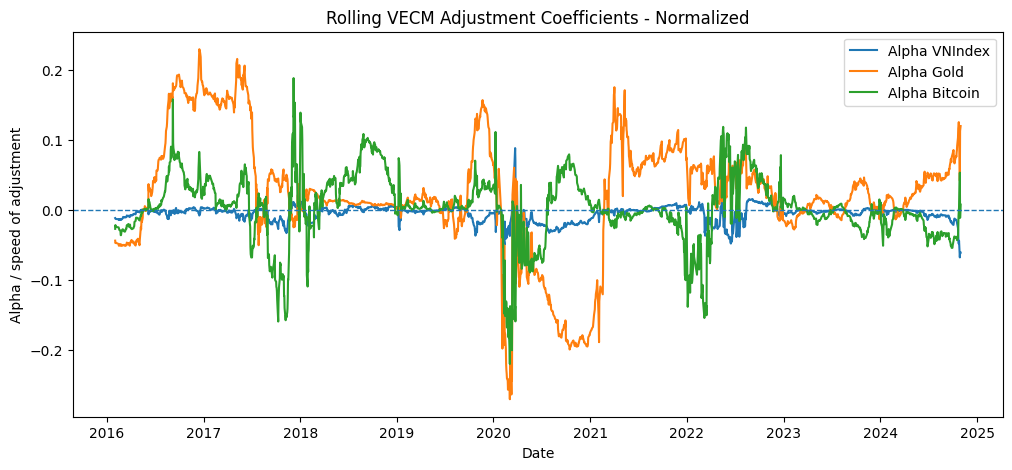

In [86]:
rolling_alpha_norm = rolling_vecm_alpha_normalized(
    levels=levels,
    window=252,
    k_ar_diff=k_ar_diff,
    coint_rank=rank_test.rank,
    deterministic="ci",
    normalize_var="ln_vnindex"
)

plt.figure(figsize=(12, 5))
plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_vnindex"], label="Alpha VNIndex")
plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_gold"], label="Alpha Gold")
plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_btc_vnd"], label="Alpha Bitcoin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling VECM Adjustment Coefficients - Normalized")
plt.ylabel("Alpha / speed of adjustment")
plt.xlabel("Date")
plt.legend()
plt.show()

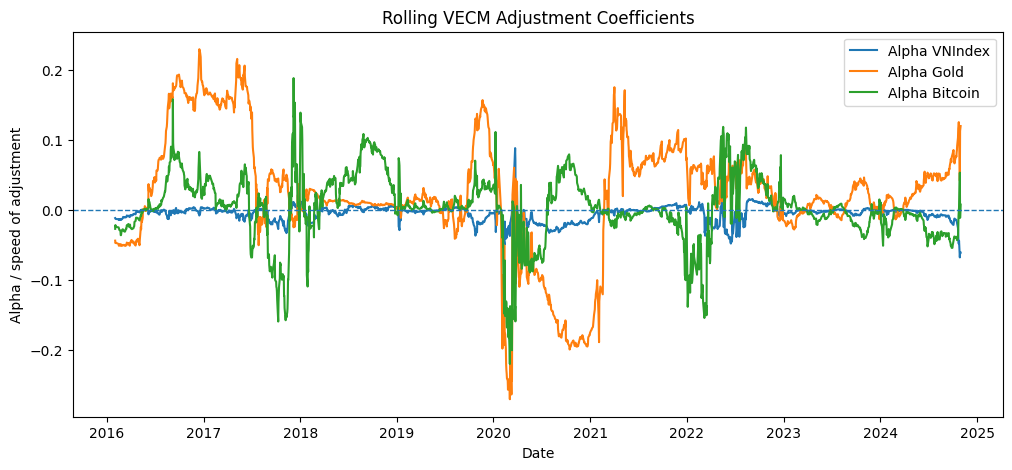

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_vnindex"], label="Alpha VNIndex")
plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_gold"], label="Alpha Gold")
plt.plot(rolling_alpha_norm.index, rolling_alpha_norm["alpha_ln_btc_vnd"], label="Alpha Bitcoin")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling VECM Adjustment Coefficients")
plt.ylabel("Alpha / speed of adjustment")
plt.xlabel("Date")
plt.legend()
plt.show()

##### Rolling Granger

In [74]:
def rolling_vecm_granger(
    levels,
    tests,
    window=252,
    k_ar_diff=1,
    coint_rank=1,
    deterministic="ci"
):
    rows = []

    for end in range(window, len(levels) + 1):
        sample = levels.iloc[end-window:end].copy()
        end_date = sample.index[-1]

        row = {"date": end_date}

        try:
            res = VECM(
                sample,
                k_ar_diff=k_ar_diff,
                coint_rank=coint_rank,
                deterministic=deterministic
            ).fit()

            for label, caused, causing in tests:
                try:
                    test_res = res.test_granger_causality(
                        caused=caused,
                        causing=causing,
                        signif=0.05
                    )

                    row[f"p_{label}"] = test_res.pvalue
                    row[f"stat_{label}"] = test_res.test_statistic

                except Exception:
                    row[f"p_{label}"] = np.nan
                    row[f"stat_{label}"] = np.nan

        except Exception:
            for label, caused, causing in tests:
                row[f"p_{label}"] = np.nan
                row[f"stat_{label}"] = np.nan

        rows.append(row)

    out = pd.DataFrame(rows).set_index("date")
    return out

In [75]:
tests = [
    ("btc_to_vnindex", ["ln_vnindex"], ["ln_btc_vnd"]),
    ("gold_to_vnindex", ["ln_vnindex"], ["ln_gold"]),
    ("vnindex_to_btc", ["ln_btc_vnd"], ["ln_vnindex"]),
    ("vnindex_to_gold", ["ln_gold"], ["ln_vnindex"]),
    ("gold_to_btc", ["ln_btc_vnd"], ["ln_gold"]),
    ("btc_to_gold", ["ln_gold"], ["ln_btc_vnd"]),
]

In [76]:
rolling_granger = rolling_vecm_granger(
    levels=levels,
    tests=tests,
    window=252,
    k_ar_diff=k_ar_diff,
    coint_rank=rank_test.rank,
    deterministic="ci"
)

print(rolling_granger.head())

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

            p_btc_to_vnindex  stat_btc_to_vnindex  p_gold_to_vnindex  \
date                                                                   
2016-02-02          0.015344             2.642895           0.839178   
2016-02-03          0.013842             2.687917           0.789479   
2016-02-04          0.018648             2.557188           0.801515   
2016-02-15          0.017254             2.591407           0.765367   
2016-02-16          0.015442             2.640109           0.768469   

            stat_gold_to_vnindex  p_vnindex_to_btc  stat_vnindex_to_btc  \
date                                                                      
2016-02-02              0.458366          0.025163             2.424200   
2016-02-03              0.525084          0.026321             2.404094   
2016-02-04              0.509332          0.022469             2.474676   
2016-02-15              0.556080          0.025209             2.423383   
2016-02-16              0.552127          0.0

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\ba

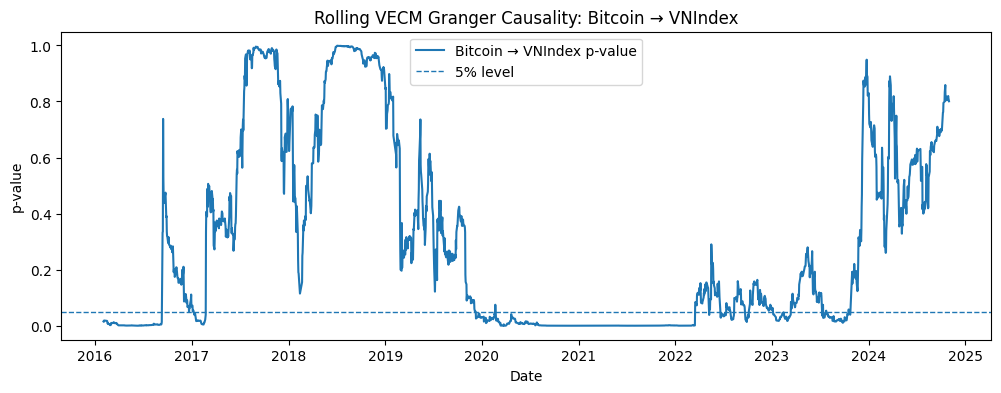

In [77]:
plt.figure(figsize=(12, 4))

plt.plot(
    rolling_granger.index,
    rolling_granger["p_btc_to_vnindex"],
    label="Bitcoin → VNIndex p-value"
)

plt.axhline(0.05, linestyle="--", linewidth=1, label="5% level")

plt.title("Rolling VECM Granger Causality: Bitcoin → VNIndex")
plt.ylabel("p-value")
plt.xlabel("Date")
plt.legend()
plt.show()

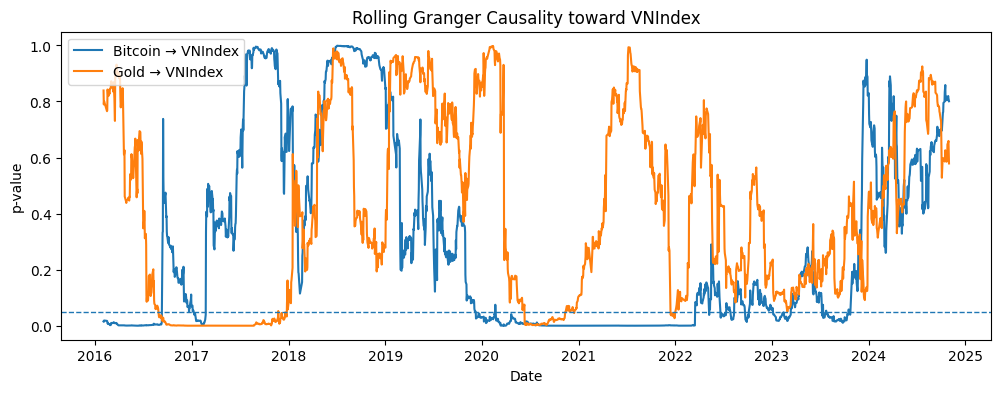

In [78]:
plt.figure(figsize=(12, 4))

plt.plot(
    rolling_granger.index,
    rolling_granger["p_btc_to_vnindex"],
    label="Bitcoin → VNIndex"
)

plt.plot(
    rolling_granger.index,
    rolling_granger["p_gold_to_vnindex"],
    label="Gold → VNIndex"
)

plt.axhline(0.05, linestyle="--", linewidth=1)

plt.title("Rolling Granger Causality toward VNIndex")
plt.ylabel("p-value")
plt.xlabel("Date")
plt.legend()
plt.show()

Kết quả Rolling VECM cho thấy các quan hệ trong hệ thống không hoàn toàn ổn định theo thời gian. Đặc biệt, kiểm định Granger cuốn chiếu cho thấy vai trò dự báo của Bitcoin đối với VN-Index có tính thời kỳ rõ rệt. Quan hệ Bitcoin → VNIndex không duy trì ổn định trong toàn bộ mẫu, nhưng trở nên rất mạnh trong giai đoạn COVID 2020–2021, khi p-value của kiểm định Granger gần như liên tục nằm dưới mức ý nghĩa 5%. Sau giai đoạn này, quan hệ vẫn xuất hiện rải rác trong năm 2022–2023 nhưng suy yếu rõ rệt vào năm 2024. Điều này cho thấy Bitcoin có thể đóng vai trò truyền dẫn thông tin/rủi ro sang thị trường chứng khoán Việt Nam trong các giai đoạn bất định cao, nhưng không phải là nhân tố chi phối ổn định trong mọi thời kỳ.

In [79]:
rolling_granger["sig_btc_to_vnindex"] = rolling_granger["p_btc_to_vnindex"] < 0.05
rolling_granger["sig_gold_to_vnindex"] = rolling_granger["p_gold_to_vnindex"] < 0.05

print("Share significant BTC → VNIndex:")
print(rolling_granger["sig_btc_to_vnindex"].mean())

print("Share significant Gold → VNIndex:")
print(rolling_granger["sig_gold_to_vnindex"].mean())

Share significant BTC → VNIndex:
0.40350877192982454
Share significant Gold → VNIndex:
0.21503759398496242


Kết quả Rolling VECM cho thấy quan hệ nhân quả Granger từ Bitcoin sang VN-Index có tính biến thiên theo thời gian. Cụ thể, Bitcoin Granger-cause VN-Index trong khoảng 40.35% số cửa sổ cuốn chiếu, cao hơn đáng kể so với vàng, với tỷ lệ khoảng 21.50%. Điều này cho thấy Bitcoin có vai trò truyền dẫn thông tin ngắn hạn sang thị trường chứng khoán Việt Nam thường xuyên hơn vàng. Tuy nhiên, do quan hệ này chỉ xuất hiện trong một phần các cửa sổ, kết quả cũng hàm ý rằng tác động của Bitcoin không ổn định trong toàn bộ giai đoạn nghiên cứu mà tập trung ở một số thời kỳ nhất định, đặc biệt trong các giai đoạn bất định cao như COVID-19.

##### Covid

In [87]:
def assign_period(date):
    if date < pd.Timestamp("2020-01-01"):
        return "Pre-COVID"
    elif date <= pd.Timestamp("2021-12-31"):
        return "COVID"
    else:
        return "Post-COVID"

rolling_granger["period"] = rolling_granger.index.to_series().apply(assign_period)
rolling_alpha_norm["period"] = rolling_alpha_norm.index.to_series().apply(assign_period)

In [81]:
period_granger_summary = rolling_granger.groupby("period").agg(
    N=("p_btc_to_vnindex", "size"),

    mean_p_btc_to_vnindex=("p_btc_to_vnindex", "mean"),
    share_sig_btc_to_vnindex=("sig_btc_to_vnindex", "mean"),

    mean_p_gold_to_vnindex=("p_gold_to_vnindex", "mean"),
    share_sig_gold_to_vnindex=("sig_gold_to_vnindex", "mean"),
)

print(period_granger_summary.round(4))

              N  mean_p_btc_to_vnindex  share_sig_btc_to_vnindex  \
period                                                             
COVID       460                 0.0043                    0.9978   
Post-COVID  628                 0.2487                    0.2691   
Pre-COVID   907                 0.4775                    0.1951   

            mean_p_gold_to_vnindex  share_sig_gold_to_vnindex  
period                                                         
COVID                       0.3939                     0.2587  
Post-COVID                  0.3767                     0.0000  
Pre-COVID                   0.4137                     0.3418  


In [ ]:
period_alpha_summary = rolling_alpha_norm.groupby("period").agg(
    mean_alpha_vnindex=("alpha_ln_vnindex", "mean"),
    mean_alpha_gold=("alpha_ln_gold", "mean"),
    mean_alpha_btc=("alpha_ln_btc_vnd", "mean"),

    share_sig_alpha_vnindex=("p_alpha_ln_vnindex", lambda x: (x < 0.05).mean()),
    share_sig_alpha_gold=("p_alpha_ln_gold", lambda x: (x < 0.05).mean()),
    share_sig_alpha_btc=("p_alpha_ln_btc_vnd", lambda x: (x < 0.05).mean()),
)

print(period_alpha_summary.round(4))

            mean_alpha_vnindex  mean_alpha_gold  mean_alpha_btc  \
period                                                            
COVID                  -0.0090          -0.0362         -0.0130   
Post-COVID             -0.0048           0.0261         -0.0026   
Pre-COVID              -0.0036           0.0517          0.0159   

            share_sig_alpha_vnindex  share_sig_alpha_gold  share_sig_alpha_btc  
period                                                                          
COVID                        0.2652                0.9674               0.0652  
Post-COVID                   0.1242                0.8901               0.5032  
Pre-COVID                    0.1676                0.9890               0.1566  


Kết quả Rolling VECM cho thấy các quan hệ giữa VN-Index, vàng và Bitcoin có tính biến thiên mạnh theo thời gian. Đặc biệt, quan hệ Granger từ Bitcoin sang VN-Index trở nên gần như liên tục có ý nghĩa trong giai đoạn COVID, với tỷ lệ cửa sổ có ý nghĩa lên tới 99.78% và mean p-value chỉ 0.0043. Điều này cho thấy Bitcoin đóng vai trò truyền dẫn thông tin/rủi ro sang thị trường chứng khoán Việt Nam mạnh nhất trong giai đoạn bất định cao. Tuy nhiên, trước và sau COVID, tỷ lệ cửa sổ có ý nghĩa thấp hơn đáng kể, cho thấy tác động này mang tính thời kỳ thay vì ổn định xuyên suốt toàn mẫu.

#### Diebold - Yilmaz

In [90]:
def diebold_yilmaz_table(theta, names):
    """
    Tạo bảng Diebold-Yilmaz từ ma trận GFEVD đã ở dạng phần trăm.
    """
    theta = np.asarray(theta)
    k = theta.shape[0]

    theta_df = pd.DataFrame(
        theta,
        index=names,
        columns=names
    )

    own = np.diag(theta)

    from_others = theta.sum(axis=1) - own
    to_others = theta.sum(axis=0) - own
    net = to_others - from_others

    tci = from_others.sum() / k

    summary = pd.DataFrame({
        "TO others": to_others,
        "FROM others": from_others,
        "NET": net,
        "Role": np.where(net > 0, "Net transmitter", "Net receiver")
    }, index=names)

    return theta_df, summary, tci

In [91]:
names = levels.columns.tolist()

for H in [10, 20]:
    theta = gfevd_10*100 if H == 10 else gfevd_20*100
    theta_df, dy_summary, tci = diebold_yilmaz_table(theta, names)

    print("\n" + "="*80)
    print(f"Diebold-Yilmaz spillover table, H={H}")
    print(theta_df.round(2))

    print(f"\nDirectional spillover summary, H={H}")
    print(dy_summary.round(2))

    print(f"\nTotal Connectedness Index, H={H}: {tci:.2f}%")


Diebold-Yilmaz spillover table, H=10
            ln_vnindex  ln_gold  ln_btc_vnd
ln_vnindex       93.45     0.40        6.15
ln_gold           0.12    99.69        0.19
ln_btc_vnd        0.41     0.12       99.47

Directional spillover summary, H=10
            TO others  FROM others   NET             Role
ln_vnindex       0.53         6.55 -6.01     Net receiver
ln_gold          0.52         0.31  0.21  Net transmitter
ln_btc_vnd       6.33         0.53  5.80  Net transmitter

Total Connectedness Index, H=10: 2.46%

Diebold-Yilmaz spillover table, H=20
            ln_vnindex  ln_gold  ln_btc_vnd
ln_vnindex       89.65     0.72        9.63
ln_gold           0.08    99.69        0.23
ln_btc_vnd        0.22     0.13       99.65

Directional spillover summary, H=20
            TO others  FROM others    NET             Role
ln_vnindex       0.30        10.35 -10.05     Net receiver
ln_gold          0.85         0.31   0.54  Net transmitter
ln_btc_vnd       9.86         0.35   9.51  Net tr

Kết quả Diebold–Yilmaz cho thấy mức độ connectedness tổng thể giữa VN-Index, vàng và Bitcoin tương đối thấp. TCI đạt 2.46% ở horizon 10 kỳ và tăng lên khoảng 3.67% ở horizon 20 kỳ, cho thấy phần lớn biến động sai số dự báo của mỗi biến vẫn được giải thích bởi cú sốc nội tại của chính nó. Tuy nhiên, trong các hiệu ứng chéo, Bitcoin nổi lên là nguồn truyền cú sốc quan trọng nhất sang VN-Index. Cụ thể, cú sốc Bitcoin giải thích 6.15% biến động dự báo của VN-Index ở H=10 và tăng lên 9.63% ở H=20.

Directional spillover cho thấy Bitcoin là net transmitter chính, với NET spillover tăng từ 5.80 ở H=10 lên 9.51 ở H=20. Ngược lại, VN-Index là net receiver rõ rệt, với NET spillover âm lần lượt là -6.01 và -10.05. Vàng có NET spillover dương nhẹ nhưng quy mô rất nhỏ, cho thấy vàng không phải là nguồn truyền cú sốc đáng kể trong hệ thống.

Nhìn chung, kết quả Diebold–Yilmaz củng cố nhận định rằng Bitcoin có vai trò truyền dẫn rủi ro/ngắn hạn sang thị trường chứng khoán Việt Nam mạnh hơn vàng, trong khi vàng duy trì mức độ kết nối thấp hơn và tương đối độc lập hơn trong hệ thống.

### Robustness

#### 1. VAR on return

In [92]:
returns = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].diff().dropna()

returns.columns = ["r_vnindex", "r_gold", "r_btc_vnd"]

print(returns.head())

               r_vnindex    r_gold  r_btc_vnd
standard_time                                
2015-01-07      0.004339 -0.015012   0.039840
2015-01-08      0.002569 -0.039453  -0.041945
2015-01-09      0.028955  0.037124   0.023961
2015-01-12      0.008024 -0.038335  -0.091169
2015-01-13      0.010875  0.067356  -0.152284


In [94]:
from statsmodels.tsa.api import VAR

var_model = VAR(returns)

lag_select = var_model.select_order(maxlags=10)
print(lag_select.summary())

p_var = lag_select.hqic
print("Selected VAR lag:", p_var)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.88     -21.88*   3.136e-10      -21.88
1       -21.90      -21.87   3.079e-10      -21.89
2       -21.90      -21.85   3.073e-10      -21.88
3       -21.92      -21.84   3.019e-10      -21.89
4       -21.95      -21.86   2.919e-10      -21.92
5       -21.97      -21.85   2.875e-10     -21.92*
6       -21.97      -21.83   2.867e-10      -21.92
7       -21.98      -21.81   2.852e-10      -21.92
8       -21.98      -21.79   2.847e-10      -21.91
9      -21.98*      -21.77  2.840e-10*      -21.90
10      -21.98      -21.74   2.847e-10      -21.89
--------------------------------------------------
Selected VAR lag: 5


c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [95]:
var_res = var_model.fit(p_var)
print(var_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 28, May, 2026
Time:                     11:41:15
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -21.8376
Nobs:                     2240.00    HQIC:                  -21.9153
Log likelihood:           15108.0    FPE:                2.90326e-10
AIC:                     -21.9600    Det(Omega_mle):     2.84192e-10
--------------------------------------------------------------------
Results for equation r_vnindex
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000162         0.000255            0.632           0.527
L1.r_vnindex         0.036137         0.021185            1.706           0.088
L1.r_gold            0.001902         0.008416            0.

In [96]:
tests_var = [
    ("Bitcoin → VNIndex", "r_vnindex", ["r_btc_vnd"]),
    ("Gold → VNIndex", "r_vnindex", ["r_gold"]),
    ("Gold + Bitcoin → VNIndex", "r_vnindex", ["r_gold", "r_btc_vnd"]),
    ("VNIndex → Bitcoin", "r_btc_vnd", ["r_vnindex"]),
    ("VNIndex → Gold", "r_gold", ["r_vnindex"]),
]

var_granger_results = []

for label, caused, causing in tests_var:
    test = var_res.test_causality(
        caused=caused,
        causing=causing,
        kind="wald"
    )
    
    var_granger_results.append({
        "Test": label,
        "Test statistic": test.test_statistic,
        "p-value": test.pvalue,
        "Reject H0 at 5%": test.pvalue < 0.05
    })

var_granger_table = pd.DataFrame(var_granger_results)
print(var_granger_table)

                       Test  Test statistic   p-value  Reject H0 at 5%
0         Bitcoin → VNIndex       27.205697  0.000052             True
1            Gold → VNIndex        5.895241  0.316546            False
2  Gold + Bitcoin → VNIndex       32.626476  0.000315             True
3         VNIndex → Bitcoin        3.904949  0.563181            False
4            VNIndex → Gold        2.950893  0.707557            False


Kết quả không phụ thuộc vào việc dùng VECM level hay VAR return.

#### 2. Weekly data

In [97]:
weekly_log_price = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].resample("W-FRI").last().dropna()

weekly_returns = weekly_log_price.diff().dropna()
weekly_returns.columns = ["r_vnindex", "r_gold", "r_btc_vnd"]

print(weekly_log_price.head())
print(weekly_returns.head())

               ln_vnindex    ln_gold  ln_btc_vnd
standard_time                                   
2015-01-09       6.345163  17.350656   15.647828
2015-01-16       6.354040  17.382505   15.298435
2015-01-23       6.367123  17.388979   15.426986
2015-01-30       6.356229  17.379110   15.399070
2015-02-06       6.352856  17.367424   15.371333
               r_vnindex    r_gold  r_btc_vnd
standard_time                                
2015-01-16      0.008877  0.031849  -0.349394
2015-01-23      0.013084  0.006474   0.128552
2015-01-30     -0.010894 -0.009869  -0.027916
2015-02-06     -0.003373 -0.011686  -0.027737
2015-02-13      0.022578  0.013668   0.059385


In [100]:
weekly_var = VAR(weekly_returns)

weekly_lag_select = weekly_var.select_order(maxlags=8)
print(weekly_lag_select.summary())

p_weekly = max(1, weekly_lag_select.hqic)

weekly_var_res = weekly_var.fit(p_weekly)
print(weekly_var_res.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -17.90      -17.88   1.678e-08      -17.89
1      -18.12      -18.02   1.353e-08      -18.08
2      -18.18      -18.00   1.271e-08      -18.11
3      -18.39     -18.14*   1.031e-08     -18.29*
4      -18.40      -18.07   1.019e-08      -18.27
5      -18.38      -17.98   1.042e-08      -18.22
6      -18.38      -17.90   1.039e-08      -18.19
7      -18.37      -17.82   1.049e-08      -18.15
8     -18.42*      -17.79  9.991e-09*      -18.17
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 28, May, 2026
Time:                     11:45:49
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -18.1649
Nobs:                     505.000    

c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [101]:
weekly_granger_results = []

for label, caused, causing in tests_var:
    test = weekly_var_res.test_causality(
        caused=caused,
        causing=causing,
        kind="wald"
    )
    
    weekly_granger_results.append({
        "Test": label,
        "p-value": test.pvalue,
        "Reject H0 at 5%": test.pvalue < 0.05
    })

weekly_granger_table = pd.DataFrame(weekly_granger_results)
print(weekly_granger_table)

                       Test   p-value  Reject H0 at 5%
0         Bitcoin → VNIndex  0.236308            False
1            Gold → VNIndex  0.092461            False
2  Gold + Bitcoin → VNIndex  0.092703            False
3         VNIndex → Bitcoin  0.844414            False
4            VNIndex → Gold  0.942109            False


Kết quả weekly VAR làm yếu bớt kết luận về spillover Bitcoin → VNIndex ở tần suất thấp hơn. Do đó, ảnh hưởng của Bitcoin nên được hiểu là tác động ngắn hạn ở tần suất ngày, đặc biệt rõ trong giai đoạn COVID, chứ không phải một quan hệ ổn định và bền vững ở mọi tần suất dữ liệu.

#### 3. VAR return on BTC/USD

In [102]:
levels_usd = log_price[["ln_vnindex", "ln_gold", "ln_btc_usd"]].dropna()

returns_usd = levels_usd.diff().dropna()
returns_usd.columns = ["r_vnindex", "r_gold", "r_btc_usd"]

In [104]:
var_usd = VAR(returns_usd)

lag_usd = var_usd.select_order(maxlags=10)
print(lag_usd.summary())

p_usd = max(1, lag_usd.hqic)

var_usd_res = var_usd.fit(p_usd)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.89     -21.88*   3.125e-10      -21.88
1       -21.91      -21.87   3.067e-10      -21.89
2       -21.91      -21.85   3.062e-10      -21.89
3       -21.93      -21.85   3.007e-10      -21.90
4       -21.96      -21.86   2.907e-10      -21.92
5       -21.97      -21.85   2.864e-10     -21.93*
6       -21.98      -21.83   2.856e-10      -21.92
7       -21.98      -21.81   2.841e-10      -21.92
8       -21.98      -21.79   2.836e-10      -21.91
9      -21.99*      -21.77  2.829e-10*      -21.91
10      -21.98      -21.75   2.836e-10      -21.90
--------------------------------------------------


c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [105]:
test_btc_usd = var_usd_res.test_causality(
    caused="r_vnindex",
    causing=["r_btc_usd"],
    kind="wald"
)

print(test_btc_usd.summary())

Granger causality Wald-test. H_0: r_btc_usd does not Granger-cause r_vnindex. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         27.90          11.07   0.000  5
----------------------------------------


Kết quả Bitcoin → VNIndex không chỉ do quy đổi tỷ giá VND, mà phản ánh tín hiệu từ thị trường Bitcoin toàn cầu.

#### 4. USD/VND control

In [107]:
returns_control = log_price[
    ["ln_vnindex", "ln_gold", "ln_btc_vnd", "ln_usdvnd"]
].diff().dropna()

returns_control.columns = ["r_vnindex", "r_gold", "r_btc_vnd", "r_usdvnd"]

var_control = VAR(returns_control)

lag_control = var_control.select_order(maxlags=10)
print(lag_control.summary())

p_control = max(1, lag_control.hqic)

var_control_res = var_control.fit(p_control)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -34.84     -34.83*   7.417e-16      -34.83
1       -34.86      -34.81   7.261e-16      -34.84
2       -34.86      -34.77   7.247e-16      -34.83
3       -34.88      -34.75   7.095e-16      -34.83
4       -34.92      -34.75   6.836e-16      -34.86
5       -34.94      -34.72   6.727e-16     -34.86*
6       -34.94      -34.68   6.710e-16      -34.84
7      -34.94*      -34.64  6.706e-16*      -34.83
8       -34.94      -34.60   6.718e-16      -34.81
9       -34.93      -34.56   6.733e-16      -34.80
10      -34.93      -34.51   6.767e-16      -34.78
--------------------------------------------------


c:\Assigment\2025-2026\Time Series Analysis\Digital-gold-debate\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [108]:
test_btc_control = var_control_res.test_causality(
    caused="r_vnindex",
    causing=["r_btc_vnd"],
    kind="wald"
)

print(test_btc_control.summary())

Granger causality Wald-test. H_0: r_btc_vnd does not Granger-cause r_vnindex. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         27.66          11.07   0.000  5
----------------------------------------


Bitcoin’s predictive role remains after controlling for USD/VND movements.

#### 5.EWMA with alternative lambda

In [114]:
returns = log_price[["ln_vnindex", "ln_gold", "ln_btc_vnd"]].diff().dropna()

r_m = returns["ln_vnindex"]

q10 = r_m.quantile(0.10)
q5  = r_m.quantile(0.05)
q1  = r_m.quantile(0.01)

stress_df = pd.DataFrame(index=returns.index)
stress_df["r_vnindex"] = r_m

stress_df["normal"] = r_m > q10
stress_df["stress_10"] = r_m <= q10
stress_df["stress_5"]  = r_m <= q5
stress_df["stress_1"]  = r_m <= q1

print("q10:", q10, "≈", (np.exp(q10) - 1) * 100, "%")
print("q5:", q5, "≈", (np.exp(q5) - 1) * 100, "%")
print("q1:", q1, "≈", (np.exp(q1) - 1) * 100, "%")

q10: -0.011979757954466309 ≈ -1.190828634303931 %
q5: -0.018760192549003917 ≈ -1.8585315420467485 %
q1: -0.0426991988101733 ≈ -4.1800425706182365 %


In [115]:
def ewma_regime_summary_for_lambda(
    u,
    stress_df,
    lam=0.94,
    init_window=60
):
    ewma_corr = compute_ewma_corr(
        u,
        lam=lam,
        init_window=init_window
    )

    ewma_stress = ewma_corr.join(stress_df, how="inner")

    summary_rows = []

    for regime, mask_col in [
        ("Normal", "normal"),
        ("Stress 10%", "stress_10"),
        ("Stress 5%", "stress_5"),
        ("Stress 1%", "stress_1")
    ]:
        temp = ewma_stress.loc[ewma_stress[mask_col]].copy()

        summary_rows.append({
            "lambda": lam,
            "Regime": regime,
            "N": len(temp),

            "Mean EWMA corr VN-Gold": temp["rho_vn_gold"].mean(),
            "Median EWMA corr VN-Gold": temp["rho_vn_gold"].median(),
            "Share negative VN-Gold": (temp["rho_vn_gold"] < 0).mean(),

            "Mean EWMA corr VN-BTC": temp["rho_vn_btc"].mean(),
            "Median EWMA corr VN-BTC": temp["rho_vn_btc"].median(),
            "Share negative VN-BTC": (temp["rho_vn_btc"] < 0).mean(),

            "Mean EWMA corr Gold-BTC": temp["rho_gold_btc"].mean(),
            "Median EWMA corr Gold-BTC": temp["rho_gold_btc"].median(),
            "Share negative Gold-BTC": (temp["rho_gold_btc"] < 0).mean()
        })

    summary = pd.DataFrame(summary_rows)

    return summary, ewma_corr, ewma_stress

In [116]:
lambda_list = [0.90, 0.94, 0.97]

all_summaries = []
ewma_corr_dict = {}
ewma_stress_dict = {}

for lam in lambda_list:
    summary, ewma_corr, ewma_stress = ewma_regime_summary_for_lambda(
        u=u,
        stress_df=stress_df,
        lam=lam,
        init_window=60
    )

    all_summaries.append(summary)
    ewma_corr_dict[lam] = ewma_corr
    ewma_stress_dict[lam] = ewma_stress

ewma_all_summary = pd.concat(all_summaries, axis=0).reset_index(drop=True)

print(ewma_all_summary.round(4))

    lambda      Regime     N  Mean EWMA corr VN-Gold  \
0     0.90      Normal  1957                 -0.0016   
1     0.90  Stress 10%   223                  0.0228   
2     0.90   Stress 5%   112                  0.0240   
3     0.90   Stress 1%    23                 -0.0513   
4     0.94      Normal  1957                 -0.0067   
5     0.94  Stress 10%   223                  0.0186   
6     0.94   Stress 5%   112                  0.0195   
7     0.94   Stress 1%    23                 -0.0516   
8     0.97      Normal  1957                 -0.0083   
9     0.97  Stress 10%   223                  0.0181   
10    0.97   Stress 5%   112                  0.0169   
11    0.97   Stress 1%    23                 -0.0309   

    Median EWMA corr VN-Gold  Share negative VN-Gold  Mean EWMA corr VN-BTC  \
0                     0.0092                  0.4854                 0.0661   
1                     0.0341                  0.4350                 0.0644   
2                     0.0390      

In [118]:
compact_cols = [
    "lambda",
    "Regime",
    "N",
    "Mean EWMA corr VN-Gold",
    "Median EWMA corr VN-Gold",
    "Share negative VN-Gold",
    "Mean EWMA corr VN-BTC",
    "Median EWMA corr VN-BTC",
    "Share negative VN-BTC"
]

ewma_compact_summary = ewma_all_summary[compact_cols]

ewma_compact_summary

,lambda,Regime,N,Mean EWMA corr VN-Gold,Median EWMA corr VN-Gold,Share negative VN-Gold,Mean EWMA corr VN-BTC,Median EWMA corr VN-BTC,Share negative VN-BTC
0,0.90,Normal,1957,-0.001554,0.009243,0.485437,0.066058,0.077426,0.359734
1,0.90,Stress 10%,223,0.022808,0.034112,0.434978,0.064360,0.059604,0.412556
2,0.90,Stress 5%,112,0.023953,0.039037,0.455357,0.077515,0.062388,0.419643
3,0.90,Stress 1%,23,-0.051348,-0.077653,0.565217,0.115288,0.044961,0.434783
4,0.94,Normal,1957,-0.006703,-0.001155,0.502299,0.064830,0.075285,0.331630
5,0.94,Stress 10%,223,0.018623,0.037981,0.443946,0.072459,0.049802,0.345291
6,0.94,Stress 5%,112,0.019499,0.043538,0.446429,0.079811,0.048281,0.366071
7,0.94,Stress 1%,23,-0.051642,-0.055828,0.565217,0.125650,0.027289,0.434783
8,0.97,Normal,1957,-0.008341,-0.007231,0.515074,0.062117,0.057273,0.305059
9,0.97,Stress 10%,223,0.018064,0.036603,0.394619,0.079167,0.064087,0.278027


EWMA results are further checked using alternative decay factors of 0.90, 0.94, and 0.97. The results remain broadly consistent for Bitcoin, whose correlation with VN-Index stays positive during stress periods. In contrast, the evidence for gold is more state-dependent, with negative correlations appearing mainly under extreme stress regimes.

#### 6. HAC with different lags

In [119]:
for lag in [5, 10, 20]:
    gold_model_lag, _, _ = safe_haven_test_residual(
        safe_df,
        asset_col="u_gold",
        hac_lags=lag
    )

    btc_model_lag, _, _ = safe_haven_test_residual(
        safe_df,
        asset_col="u_btc_vnd",
        hac_lags=lag
    )

    print("\nHAC lag:", lag)
    print("Gold total slopes")
    print(total_slope_tests(gold_model_lag))

    print("Bitcoin total slopes")
    print(total_slope_tests(btc_model_lag))


HAC lag: 5
Gold total slopes
                         Slope  Estimate   Std.Err    t-stat   p-value  \
0              Normal slope β0  0.044006  0.088975  0.494581  0.620896   
1       10% stress slope β0+β1 -0.256871  0.118258 -2.172113  0.029847   
2     5% stress slope β0+β1+β2 -0.121324  0.101984 -1.189643  0.234187   
3  1% stress slope β0+β1+β2+β3 -0.181120  0.190918 -0.948680  0.342784   

   Significant 5%  
0           False  
1            True  
2           False  
3           False  
Bitcoin total slopes
                         Slope  Estimate   Std.Err    t-stat   p-value  \
0              Normal slope β0  0.165531  0.133123  1.243444  0.213704   
1       10% stress slope β0+β1  0.284205  0.264145  1.075944  0.281952   
2     5% stress slope β0+β1+β2  0.014529  0.207899  0.069886  0.944284   
3  1% stress slope β0+β1+β2+β3  0.909604  0.505620  1.798985  0.072021   

   Significant 5%  
0           False  
1           False  
2           False  
3           False  

HAC la

Gold tốt hơn Bitcoin
Bitcoin không safe haven